# Análisis de Series Temporales — TP1
### Movilidad Urbana en Buenos Aires: Subte, Peajes y Precipitaciones

**Universidad Austral · Maestría de Ciencia de Datos**  

**Integrantes:**
- Alvaro, Giuliana
- Chalup, Sarah
- Fontán, Mariana
- Franco, Agustina

## Setup librerías e Imports

In [1]:
# ── Manipulación de datos ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# ── Series temporales ─────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

# ── Métricas ──────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# ── Descarga de datos ─────────────────────────────────────────────────────
import requests
import zipfile
import io
import os
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Configuración de plots ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (14, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# ── Directorio de datos ────────────────────────────────────────────────────
DATA_DIR = Path('datos_tp1')
DATA_DIR.mkdir(exist_ok=True)

print('Setup completo ✓')

Setup completo ✓


## 1. Creación de los Datasets

### ⚡ Carga Rápida

Si ya descargaste los datos al menos una vez, **ejecutá solo esta celda** y se ignora la carga de los datasets anuales

In [2]:
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('datos_tp1')

NECESARIOS = ['subte_mensual.csv', 'lluvia_mensual.csv', 'peajes_mensual.csv']
faltantes  = [f for f in NECESARIOS if not (DATA_DIR / f).exists()]

if faltantes:
    print(f'⚠️  Faltan archivos: {faltantes}')
    print('   Corré primero la Sección 1 (Descarga y Procesamiento de Datos).')
else:
    subte_mensual  = pd.read_csv(DATA_DIR / 'subte_mensual.csv',
                                  index_col=0, parse_dates=True).squeeze()
    lluvia_mensual = pd.read_csv(DATA_DIR / 'lluvia_mensual.csv',
                                  index_col=0, parse_dates=True).squeeze()
    peajes_mensual = pd.read_csv(DATA_DIR / 'peajes_mensual.csv',
                                  index_col=0, parse_dates=True).squeeze()

    START, END  = '2013-06-01', '2025-12-01'
    TRAIN_END   = '2023-12-01'
    TEST_START  = '2024-01-01'

    df = pd.DataFrame({
        'pasajeros_subte':  subte_mensual,
        'vehiculos_peajes': peajes_mensual,
        'lluvia_mm':        lluvia_mensual,
    }).loc[START:END]
    df['dummy_covid'] = 0
    df.loc['2020-03-01':'2021-12-01', 'dummy_covid'] = 1

    train = df.loc[:TRAIN_END]
    test  = df.loc[TEST_START:]

    print('✅ Datos cargados correctamente. Podés saltar a la Sección 2.')
    print(f'   Período  : {df.index[0].date()} -> {df.index[-1].date()} ({len(df)} obs)')
    print(f'   Train    : {train.index[0].date()} -> {train.index[-1].date()} ({len(train)} obs)')
    print(f'   Test     : {test.index[0].date()} -> {test.index[-1].date()} ({len(test)} obs)')
    print(f'   COVID    : {df["dummy_covid"].sum()} meses marcados')
    display(df.tail())

⚠️  Faltan archivos: ['subte_mensual.csv']
   Corré primero la Sección 1 (Descarga y Procesamiento de Datos).


### 1.1 Data precipitaciones - MeteoAPI

In [3]:
def descargar_precipitaciones(start='2013-06-01', end='2025-12-31'):
    """Descarga datos diarios de precipitación de Open-Meteo y agrega a mensual."""
    url = (
        f"https://archive-api.open-meteo.com/v1/archive"
        f"?latitude=-34.60&longitude=-58.37"
        f"&start_date={start}&end_date={end}"
        f"&daily=precipitation_sum"
        f"&timezone=America%2FArgentina%2FBuenos_Aires"
        f"&format=csv"
    )
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    
    # El CSV de Open-Meteo tiene 3 líneas de encabezado
    df = pd.read_csv(io.StringIO(resp.text), skiprows=3, parse_dates=['time'])
    df = df.rename(columns={'time': 'fecha', 'precipitation_sum (mm)': 'lluvia_mm'})
    df = df.set_index('fecha')
    
    # Agregar a mensual
    lluvia_mensual = df['lluvia_mm'].resample('MS').sum()
    lluvia_mensual.name = 'lluvia_mm'
    return lluvia_mensual

lluvia = descargar_precipitaciones()
lluvia.to_csv(DATA_DIR / 'lluvia_mensual.csv')
print(f'Precipitaciones: {len(lluvia)} observaciones mensuales')
print(f'Período: {lluvia.index[0].date()} → {lluvia.index[-1].date()}')
lluvia.head()

Precipitaciones: 151 observaciones mensuales
Período: 2013-06-01 → 2025-12-01


fecha
2013-06-01      8.6
2013-07-01     78.2
2013-08-01      6.8
2013-09-01    102.4
2013-10-01     27.5
Freq: MS, Name: lluvia_mm, dtype: float64

### 1.2 Subte - Molinetes GCBA
> Los archivos CSV/ZIP se descargan desde el portal de datos abiertos del GCBA.  
> Por el tamaño de los archivos, se procesan año por año y se consolidan en un único CSV mensual.

In [5]:
# ── URLs verificadas (abril 2026) ─────────────────────────────────────────
SUBTE_URLS = {
    2013: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2013-junio-diciembre.zip',
    2014: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2014.zip',
    2015: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2015.zip',
    2016: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2016.zip',
    2017: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2017.zip',
    2018: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2018.zip',
    2019: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2019.zip',
    2020: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2020.zip',
    2021: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2021.zip',
    2022: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2022.zip',
    2023: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2023.zip',
    2024: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2024.zip',
    2025: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2025.zip',
}

def limpiar_raw(raw_bytes):
    """
    Quita BOM y comillas externas de cada línea.
    El portal GCBA envuelve cada fila entre comillas dobles en 2022-2025:
      \"1/1/2022;08:00:00;...;1\"  ->  1/1/2022;08:00:00;...;1
    Devuelve (bytes_limpios, encoding).
    """
    if raw_bytes.startswith(b'\xef\xbb\xbf'):
        raw_bytes = raw_bytes[3:]
        enc = 'utf-8'
    else:
        enc = 'latin1'

    texto = raw_bytes.decode(enc)
    lineas = texto.splitlines()

    # Solo limpiar comillas externas si TODA la fila es una sola cadena quotada
    # (formato 2022-2025 con separador ';' donde la fila entera va entre comillas)
    # NO tocar formato 2013-2021 con campos individualmente quotados ("A","B","C")
    primera = lineas[0].strip() if lineas else ''
    if primera.startswith('"') and primera.endswith('"') and ';' in primera:
        lineas = [l.strip().strip('"') for l in lineas if l.strip()]

    limpio = '\n'.join(lineas).encode(enc)
    return limpio, enc

def _parsear_csv_subte(raw_bytes):
    """Parsea un CSV de molinetes GCBA → DataFrame con [fecha, pax]."""
    raw_limpio, enc = limpiar_raw(raw_bytes)
    primera = raw_limpio.split(b'\n')[0].decode(enc)
    sep = ';' if ';' in primera else ','
    df = pd.read_csv(io.BytesIO(raw_limpio), sep=sep, encoding=enc, low_memory=False)
    df.columns = df.columns.str.strip().str.lower()
    if 'fecha' not in df.columns:
        return pd.DataFrame(columns=['fecha', 'pax'])
    # Seleccionar columna de pasajeros TOTALES (no solo pagos)
    for candidate in ['pax_total', 'total']:
        if candidate in df.columns:
            pax_col = candidate
            break
    else:
        pax_col = next((c for c in df.columns if 'total' in c), None)
    if pax_col is None:
        return pd.DataFrame(columns=['fecha', 'pax'])
    df['pax'] = pd.to_numeric(df[pax_col], errors='coerce')
    # Detectar formato de fecha: ISO (YYYY-MM-DD) vs argentino (D/M/YYYY o DD/MM/YYYY)
    muestra = df['fecha'].dropna().iloc[0] if not df['fecha'].dropna().empty else ''
    if str(muestra).count('-') == 2 and str(muestra).index('-') == 4:
        # Formato ISO: YYYY-MM-DD — NO usar dayfirst (causa NaT para días > 12)
        df['fecha'] = pd.to_datetime(df['fecha'], format='%Y-%m-%d', errors='coerce')
    else:
        # Formato argentino: D/M/YYYY o DD/MM/YYYY
        df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
    return df[['fecha', 'pax']].dropna()

def procesar_subte_anio(url, anio):
    """
    Descarga un ZIP anual de molinetes y devuelve [fecha, pax].
    Maneja todos los formatos del portal GCBA (2013-2025), incluyendo
    ZIPs con múltiples CSV por mes (2022-2025: líneas ABC + DEH).
    """
    cache_path = DATA_DIR / f'subte_{anio}.csv'
    if cache_path.exists():
        print(f'  {anio}: cache local OK')
        return pd.read_csv(cache_path, parse_dates=['fecha'])

    print(f'  {anio}: descargando...', end=' ', flush=True)
    try:
        resp = requests.get(url, timeout=300)
        resp.raise_for_status()

        z = zipfile.ZipFile(io.BytesIO(resp.content))
        csv_names = [n for n in z.namelist() if n.lower().endswith('.csv')]

        # Leer TODOS los CSV del ZIP (2022-2025 tiene 2 por mes: ABC + DEH)
        frames = []
        for csv_name in csv_names:
            raw = z.open(csv_name).read()
            df_part = _parsear_csv_subte(raw)
            if not df_part.empty:
                frames.append(df_part)

        if not frames:
            raise ValueError('No se pudo parsear ningún CSV del ZIP')

        out = pd.concat(frames, ignore_index=True)
        out.to_csv(cache_path, index=False)
        print(f'OK  ({len(csv_names)} CSVs | {len(out):,} registros)')
        return out

    except Exception as e:
        print(f'ERROR: {e}')
        return pd.DataFrame(columns=['fecha', 'pax'])

# ── Descargar / leer desde caché ──────────────────────────────────────────
print('Procesando subte por año...')
frames = [procesar_subte_anio(url, anio) for anio, url in SUBTE_URLS.items()]
subte_raw = pd.concat([f for f in frames if not f.empty], ignore_index=True)

if subte_raw.empty:
    print('\n⚠️  No se cargó ningún año.')
else:
    import calendar
    subte_raw['fecha'] = pd.to_datetime(subte_raw['fecha'])

    # Escalar por días disponibles: muchos años del portal GCBA solo tienen
    # ~12 días por mes (datos incompletos). Calculamos promedio diario × días reales.
    subte_raw['mes'] = subte_raw['fecha'].dt.to_period('M')
    subte_raw['dia'] = subte_raw['fecha'].dt.date
    g = subte_raw.groupby('mes').agg(
        pax_total=('pax', 'sum'),
        dias_con_datos=('dia', 'nunique')
    ).reset_index()
    g['fecha'] = g['mes'].dt.to_timestamp()
    g['dias_en_mes'] = g['fecha'].apply(lambda d: calendar.monthrange(d.year, d.month)[1])
    g['pasajeros'] = (g['pax_total'] / g['dias_con_datos'] * g['dias_en_mes']).round(0)
    g['cobertura_pct'] = (g['dias_con_datos'] / g['dias_en_mes'] * 100).round(1)

    subte_mensual = g.set_index('fecha')['pasajeros']
    subte_mensual.name = 'pasajeros'
    subte_mensual.to_csv(DATA_DIR / 'subte_mensual.csv')
    print(f'\n✅ subte_mensual.csv guardado — {len(subte_mensual)} meses')
    print(f'   Período: {subte_mensual.index[0].date()} -> {subte_mensual.index[-1].date()}')
    print('\n   Cobertura de días por año:')
    cob = g.groupby(g['fecha'].dt.year)['cobertura_pct'].mean().round(1)
    for yr, pct in cob.items():
        flag = ' ⚠ escalado' if pct < 95 else ' ✓'
        print(f'     {yr}: {pct:.1f}%{flag}')
    display(subte_mensual.head(8))

Procesando subte por año...
  2013: descargando... OK  (1 CSVs | 2,432,466 registros)
  2014: descargando... OK  (1 CSVs | 4,229,183 registros)
  2015: descargando... OK  (1 CSVs | 4,288,027 registros)
  2016: descargando... OK  (1 CSVs | 11,542,322 registros)
  2017: descargando... OK  (1 CSVs | 11,938,476 registros)
  2018: descargando... OK  (1 CSVs | 4,824,284 registros)
  2019: descargando... OK  (1 CSVs | 5,016,204 registros)
  2020: descargando... OK  (1 CSVs | 4,124,080 registros)
  2021: descargando... OK  (1 CSVs | 7,028,067 registros)
  2022: descargando... OK  (24 CSVs | 12,136,381 registros)
  2023: descargando... OK  (24 CSVs | 10,098,877 registros)
  2024: descargando... OK  (24 CSVs | 9,768,406 registros)
  2025: descargando... OK  (26 CSVs | 11,922,979 registros)

✅ subte_mensual.csv guardado — 156 meses
   Período: 2013-01-01 -> 2025-12-01


fecha
2013-01-01    4571506.0
2013-02-01    5554035.0
2013-03-01    5675265.0
2013-04-01    6541915.0
2013-05-01    6835679.0
2013-06-01    5853952.0
2013-07-01    5135811.0
2013-08-01    5142416.0
Freq: MS, Name: pasajeros, dtype: float64

#### Bugs encontrados al cargar datos de Subte (Molinetes GCBA)

**Bug 1 — Cambio de separador entre años**

**Causa:** El portal no usa un formato consistente a lo largo de los años:

| Años | Separador |
|---|---|
| 2013–2021 | Coma `,` |
| 2022–2025 | Punto y coma `;` |

La función original asumía coma para todos los años, por lo que los años nuevos se leían como una sola columna gigante.

**Solución:** Detectar el separador automáticamente leyendo la primera línea del archivo antes de parsear.

---

**Bug 2 — Filas envueltas en comillas dobles (2022–2025)**

**Causa:** A partir de 2022, el portal exporta cada fila entera entre comillas dobles:
```
"1/1/2022;08:00:00;08:15:00;LineaA;...;1"
```
Con `sep=';'` y `quotechar='"'` (default de pandas), el parser interpreta toda la fila como **un único campo** por estar entre comillas, resultando en una sola columna con todo el contenido.

**Solución:** Pre-procesar el archivo línea por línea, stripear las comillas externas de cada fila antes de pasárselo a `pd.read_csv`.

---

**Bug 3 — BOM UTF-8 en 2023–2025**

**Causa:** Los archivos de 2023 en adelante incluyen un BOM (*Byte Order Mark*, `\xef\xbb\xbf`) al inicio del archivo. Al leerlos con encoding `latin1`, el BOM se convierte en los caracteres `ï»¿` que se pegan al nombre de la primera columna (`ï»¿"fecha`), impidiendo su detección.

**Solución:** Detectar el BOM en los primeros 3 bytes y strippearlo antes de procesar, cambiando el encoding a `utf-8` para esos archivos.


---

**Resumen del flujo final que funciona**

1. Descargar ZIP
2. Detectar BOM → stripear si existe, ajustar encoding
3. Pre-procesar líneas → stripear comillas externas si la primera línea las tiene
4. Detectar separador desde la primera línea ya limpia
5. pd.read_csv() con sep y encoding correctos
6. Normalizar nombres de columna (lowercase + strip)
7. Parsear fecha (dayfirst=True) y pax_total como numérico
8. Guardar caché solo si hay registros > 0


### 1.3 Peajes AUSA - Flujo vehicular

In [6]:
import unicodedata
import subprocess
import tempfile

# ── URLs verificadas (abril 2026) ─────────────────────────────────────────
_BASE_AUSA = (
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ausa/'
    'flujo-vehicular-por-unidades-de-peaje-ausa/'
)
PEAJES_URLS = {
    2013: _BASE_AUSA + 'flujo-vehicular-2013.csv',
    2014: _BASE_AUSA + 'flujo-vehicular-2014.csv',
    2015: _BASE_AUSA + 'flujo-vehicular-2015.csv',
    2016: _BASE_AUSA + 'flujo-vehicular-2016.csv',
    2017: _BASE_AUSA + 'flujo-vehicular-2017.csv',
    2018: _BASE_AUSA + 'flujo-vehicular-2018.csv',
    2019: _BASE_AUSA + 'flujo-vehicular-2019.csv',
    2020: _BASE_AUSA + 'flujo-vehicular-2020.csv',
    2021: _BASE_AUSA + 'flujo-vehicular-2021.csv',   # CSV directo ~197 MB
    2022: _BASE_AUSA + 'flujo-vehicular-2022.zip',
    2023: _BASE_AUSA + 'flujo-vehicular-2023.zip',
    2024: _BASE_AUSA + 'flujo-vehicular-2024.zip',
    2025: _BASE_AUSA + 'flujo-vehicular-2025.zip',   # en realidad es un RAR
}

# Meses en español -> número (necesario para schema 2021)
_MESES_ES = {
    'enero':1,  'febrero':2,   'marzo':3,    'abril':4,
    'mayo':5,   'junio':6,     'julio':7,    'agosto':8,
    'septiembre':9, 'octubre':10, 'noviembre':11, 'diciembre':12,
}

# ── Helpers ────────────────────────────────────────────────────────────────
def _norm(c: str) -> str:
    """Lowercase + quitar tildes + strip  (ej: 'Año' -> 'ano', 'Día' -> 'dia')."""
    c = c.strip().lower()
    c = unicodedata.normalize('NFD', c)
    return ''.join(ch for ch in c if unicodedata.category(ch) != 'Mn')

def _leer_csv_raw(raw: bytes) -> pd.DataFrame:
    """
    Lee bytes de un CSV de AUSA.
      · BOM UTF-8  -> utf-8  (y lo elimina)
      · Sin BOM    -> intenta utf-8 en la primera línea; si falla, latin1
        (los CSVs 2021+ de AUSA son UTF-8 sin BOM: 'Año' = b'\\xc3\\xb1o')
      · Detecta separador (, / ;)
      · Normaliza nombres de columna (sin tildes, lowercase)
    """
    if raw.startswith(b'\xef\xbb\xbf'):
        raw, enc = raw[3:], 'utf-8'
    else:
        primera_raw = raw.split(b'\n')[0]
        try:
            primera_raw.decode('utf-8')
            enc = 'utf-8'
        except UnicodeDecodeError:
            enc = 'latin1'

    primera = raw.split(b'\n')[0].decode(enc, errors='replace')
    sep = ';' if primera.count(';') > primera.count(',') else ','

    df = pd.read_csv(
        io.BytesIO(raw), sep=sep, encoding=enc,
        low_memory=False, on_bad_lines='skip'
    )
    df.columns = [_norm(c) for c in df.columns]
    return df

def _extraer_csvs_archivo(content: bytes) -> list:
    """
    Extrae todos los CSVs de un archivo comprimido (ZIP o RAR).
    Detecta el tipo por magic bytes:
      · b'PK'       -> ZIP  (usa zipfile)
      · b'Rar!'     -> RAR  (usa bsdtar via subprocess)
    Devuelve lista de bytes, uno por CSV.
    """
    if content.startswith(b'PK'):
        # ZIP estándar
        z = zipfile.ZipFile(io.BytesIO(content))
        csvs = [n for n in z.namelist() if n.lower().endswith('.csv')]
        if not csvs:
            raise ValueError(f'ZIP sin CSVs. Contenido: {z.namelist()}')
        return [z.open(n).read() for n in csvs]

    elif content.startswith(b'Rar!'):
        # RAR (el portal AUSA sirve 2025 como RAR con extensión .zip)
        with tempfile.TemporaryDirectory() as tmpdir:
            rar_path = Path(tmpdir) / 'archivo.rar'
            rar_path.write_bytes(content)
            result = subprocess.run(
                ['bsdtar', '-xf', str(rar_path), '-C', tmpdir],
                capture_output=True
            )
            if result.returncode != 0:
                raise ValueError(f'bsdtar error: {result.stderr.decode(errors="replace")}')
            csv_files = [p for p in Path(tmpdir).iterdir()
                         if p.suffix.lower() == '.csv']
            if not csv_files:
                raise ValueError(f'RAR sin CSVs. Archivos: {list(Path(tmpdir).iterdir())}')
            return [p.read_bytes() for p in sorted(csv_files)]

    else:
        raise ValueError(f'Formato de archivo desconocido. Magic bytes: {content[:4]}')

def _mensualizar(df: pd.DataFrame) -> pd.Series:
    """
    Detecta el schema del DataFrame y devuelve Serie mensual con suma de pasos.

    Schema VIEJO (2013-2020):
        fecha (string DD/MM/YYYY)  +  cantidad_pasos

    Schema 2021:
        ano de fecha operativa  (int año)
        mes de fecha operativa  (texto español: 'abril', 'mayo', ...)
        dia de fecha operativa  (int día)
        pasos

    Schema 2022-2025 (CSVs dentro del archivo comprimido):
        ano de fecha operativa  (fecha completa: '1/4/2022')  <- nombre engañoso!
        pasos
        ** NO existen columnas mes/dia separadas **
    """
    cols = set(df.columns)

    # ── Schema viejo (2013-2020) ──────────────────────────────────────────
    if 'fecha' in cols and 'cantidad_pasos' in cols:
        df = df[['fecha', 'cantidad_pasos']].copy()
        df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
        df['pasos'] = pd.to_numeric(df['cantidad_pasos'], errors='coerce')

    # ── Schemas nuevos: existe alguna columna 'ano...operativa' ───────────
    elif any('ano' in c and 'operativa' in c for c in cols):
        ano_col = next(c for c in cols if 'ano' in c and 'operativa' in c)
        pas_col = 'pasos' if 'pasos' in cols else next(
            (c for c in cols if 'paso' in c), None
        )
        if pas_col is None:
            raise ValueError(f'Columna "pasos" no encontrada. Cols: {sorted(cols)}')

        df[pas_col] = pd.to_numeric(df[pas_col], errors='coerce')

        if 'dia de fecha operativa' in cols:
            # ── Schema 2021: año(int) + mes(texto español) + día(int) ────
            mes_col = next(c for c in cols if 'mes' in c and 'operativa' in c)
            dia_col = 'dia de fecha operativa'

            df[ano_col] = pd.to_numeric(df[ano_col], errors='coerce')
            df[dia_col] = pd.to_numeric(df[dia_col], errors='coerce')
            df['_mes_n'] = df[mes_col].str.lower().str.strip().map(_MESES_ES)

            df = df.dropna(subset=[ano_col, '_mes_n', dia_col, pas_col])
            df['fecha'] = pd.to_datetime(dict(
                year  = df[ano_col].astype(int),
                month = df['_mes_n'].astype(int),
                day   = df[dia_col].astype(int),
            ), errors='coerce')
            df['pasos'] = df[pas_col]

        else:
            # ── Schema 2022-2025: ano_col contiene fecha completa 'DD/MM/YYYY' ──
            df['fecha'] = pd.to_datetime(df[ano_col], dayfirst=True, errors='coerce')
            df['pasos'] = df[pas_col]

    else:
        raise ValueError(f'Schema desconocido. Columnas: {sorted(cols)}')

    df = df.dropna(subset=['fecha', 'pasos'])
    return df.set_index('fecha')['pasos'].resample('MS').sum()


# ── Función principal por año ──────────────────────────────────────────────
def procesar_peajes_anio(url: str, anio: int) -> pd.Series:
    """
    Descarga un año de datos AUSA, lo mensualiza y lo cachea en
    datos_tp1/peajes_{anio}.csv.  Devuelve Serie con índice mensual (MS).
    """
    cache = DATA_DIR / f'peajes_{anio}.csv'
    if cache.exists():
        print(f'  {anio}: cache local OK')
        s = pd.read_csv(cache, index_col=0, parse_dates=True).squeeze()
        s.name = 'pasos'
        return s

    print(f'  {anio}: descargando...', end=' ', flush=True)
    try:
        resp = requests.get(url, timeout=600)
        resp.raise_for_status()

        # Detectar si es archivo comprimido por magic bytes (no por extensión)
        if resp.content[:2] == b'PK' or resp.content[:4] == b'Rar!':
            csvs_raw = _extraer_csvs_archivo(resp.content)
            partes   = [_mensualizar(_leer_csv_raw(r)) for r in csvs_raw]
            serie    = pd.concat(partes).resample('MS').sum()
        else:
            # CSV directo (formato 2013-2021)
            serie = _mensualizar(_leer_csv_raw(resp.content))

        serie.name = 'pasos'
        serie.to_csv(cache)
        print(f'OK  ({len(serie)} meses | {serie.sum():,.0f} pasos total)')
        return serie

    except Exception as e:
        print(f'ERROR: {e}')
        import traceback; traceback.print_exc()
        return pd.Series(dtype=float, name='pasos')


# ── Ejecutar descarga / lectura de caché ──────────────────────────────────
print('Procesando peajes AUSA por año...')
frames_p = [procesar_peajes_anio(url, anio) for anio, url in PEAJES_URLS.items()]
frames_p = [f for f in frames_p if not f.empty]

if not frames_p:
    print('\n⚠️  No se cargó ningún año de peajes.')
else:
    peajes_mensual = pd.concat(frames_p).sort_index().resample('MS').sum()
    peajes_mensual.name = 'vehiculos'
    peajes_mensual.to_csv(DATA_DIR / 'peajes_mensual.csv')
    print(f'\n✅ peajes_mensual.csv guardado — {len(peajes_mensual)} meses')
    print(f'   Período: {peajes_mensual.index[0].date()} → {peajes_mensual.index[-1].date()}')
    display(peajes_mensual.head(8))


Procesando peajes AUSA por año...
  2013: cache local OK
  2014: cache local OK
  2015: cache local OK
  2016: cache local OK
  2017: cache local OK
  2018: cache local OK
  2019: cache local OK
  2020: cache local OK
  2021: cache local OK
  2022: cache local OK
  2023: cache local OK
  2024: cache local OK
  2025: cache local OK

✅ peajes_mensual.csv guardado — 156 meses
   Período: 2013-01-01 → 2025-12-01


fecha
2013-01-01    3474638.0
2013-02-01    3587558.0
2013-03-01    3739465.0
2013-04-01    4027098.0
2013-05-01    3959602.0
2013-06-01    3901198.0
2013-07-01    3837807.0
2013-08-01    3982906.0
Freq: MS, Name: vehiculos, dtype: float64

#### Notas sobre los datos de Peajes AUSA

El portal de datos abiertos del GCBA cambió el formato de los archivos a lo largo de los años:

| Años | Formato | Columna fecha | Columna flujo |
|---|---|---|---|
| 2013–2020 | CSV directo | `fecha` (DD/MM/YYYY) | `cantidad_pasos` |
| 2021 | CSV directo (~197 MB) | `Año/Mes/Día de Fecha Operativa` (columnas separadas) | `Pasos` |
| 2022–2025 | ZIP con CSVs mensuales | `Año/Mes/Día de Fecha Operativa` (columnas separadas) | `Pasos` |

**Estrategia de caching:** cada año se guarda como `peajes_{año}.csv` con la serie ya mensualizada (suma de pasos por mes), lo que evita re-descargar archivos de cientos de MB en ejecuciones futuras.

**Detección de schema:** la función `_mensualizar()` detecta automáticamente qué formato usa cada archivo buscando si existe la columna `fecha` (schema viejo) o columnas que contengan `operativa` en el nombre (schema nuevo). Los nombres de columna se normalizan removiendo tildes y convirtiendo a minúsculas para robustez ante cambios de capitalización.

---

**Bug 1 — Encoding UTF-8 sin BOM (2021-2025)**

Los CSVs nuevos de AUSA son UTF-8 pero sin BOM. El código anterior defaulteaba a `latin1`, con lo que `Año` se leía como `AÃ±o` y después de `_norm()` quedaba `aa±o` en lugar de `ano`. Eso rompía toda la detección de columnas.

**Fix:** antes de asumir `latin1`, se intenta decodificar la primera línea como UTF-8. Si funciona, se usa `utf-8`; si tira `UnicodeDecodeError`, ahí sí `latin1`.

---

**Bug 2 — Dos schemas distintos dentro de "formato nuevo"**

| Año | Columna `Mes` | Cómo llega la fecha |
|---|---|---|
| 2021 | `Mes de Fecha Operativa` = `"abril"` (texto español) | 3 columnas separadas: año (int) + mes (texto) + día (int) |
| 2022–2025 | No existe | **`Año de Fecha Operativa`** trae la fecha completa: `"1/4/2022"` |

El código anterior asumía que el mes siempre era numérico (`pd.to_numeric`) → todo NaN para 2021. Y para 2022+ intentaba buscar columnas `mes`/`dia` que directamente no existen → `StopIteration`.

**Fix:** se distinguen los dos sub-schemas según si existe `dia de fecha operativa` en el DataFrame:
- Si existe → schema 2021: se mapean los meses con `_MESES_ES` y se construye la fecha
- Si no existe → schema 2022+: `ano_col` se parsea directo con `pd.to_datetime(dayfirst=True)`

Funciona. El pipeline completo de 2025 está OK — 12 CSVs extraídos del RAR, 12 meses generados.

El código ya está guardado en el notebook. Resumen del fix de este bug:

---

**Bug — 2025 es un RAR con extensión `.zip`**

El servidor devuelve el archivo con `Content-Type: application/zip`, pero los primeros bytes son `Rar!\x1a\x07` (firma RAR5). `zipfile.ZipFile` explota con `BadZipFile`.

**Fix:** se agregó `_extraer_csvs_archivo()` que detecta el tipo por **magic bytes** (no por extensión):
- `b'PK'` → ZIP estándar con `zipfile`
- `b'Rar!'` → RAR usando `bsdtar` (disponible en macOS vía Homebrew/Xcode)

Y en `procesar_peajes_anio` la lógica ahora es:
```python
if resp.content[:2] == b'PK' or resp.content[:4] == b'Rar!':
    csvs_raw = _extraer_csvs_archivo(resp.content)  # maneja ZIP y RAR
    ...
else:
    serie = _mensualizar(_leer_csv_raw(resp.content))  # CSV directo
```

**Bonus:** el schema de 2025 cambió levemente — la columna de fecha se llama `Mes, Día, Año de Fecha Operativa` en lugar de `Año de Fecha Operativa`, pero igual contiene la fecha completa `DD/MM/YYYY`. Mi `_norm()` la convierte a `mes, dia, ano de fecha operativa` que todavía matchea `'ano' in c and 'operativa' in c`, así que funciona sin cambios adicionales.

Podés correr la celda ahora. Los años 2022-2024 van a descargar ZIPs normales y 2025 va a descargar y extraer el RAR automáticamente.

### 1.4 Datasets finales

In [7]:
# ── Cargar series ya procesadas ───────────────────────────────────────────
subte   = pd.read_csv(DATA_DIR / 'subte_mensual.csv',  index_col=0, parse_dates=True).squeeze()
lluvia  = pd.read_csv(DATA_DIR / 'lluvia_mensual.csv', index_col=0, parse_dates=True).squeeze()
peajes  = pd.read_csv(DATA_DIR / 'peajes_mensual.csv', index_col=0, parse_dates=True).squeeze()

# ── Alinear al mismo período ──────────────────────────────────────────────
START, END = '2013-06-01', '2025-12-01'

df = pd.DataFrame({
    'pasajeros_subte':  subte,
    'vehiculos_peajes': peajes,
    'lluvia_mm':        lluvia,
}).loc[START:END]

# ── Filtrar outliers extremos en fuente (< 1% de la mediana) ─────────────
for col in ['pasajeros_subte', 'vehiculos_peajes']:
    mediana = df[col].median()
    df.loc[df[col] < mediana * 0.01, col] = np.nan

# ── Transformación logarítmica ────────────────────────────────────────────
# Se trabaja en log para estabilizar varianza y manejar el cambio de nivel
# post-COVID. Lluvia no se transforma (ya es estacionaria y tiene ceros).
df['log_subte']  = np.log(df['pasajeros_subte'])
df['log_peajes'] = np.log(df['vehiculos_peajes'])

print(f'Dataset consolidado: {df.shape[0]} observaciones × {df.shape[1]} variables')
print(f'Período: {df.index[0].date()} → {df.index[-1].date()}')
df[['log_subte','log_peajes','lluvia_mm']].tail()


Dataset consolidado: 151 observaciones × 5 variables
Período: 2013-06-01 → 2025-12-01


,log_subte,log_peajes,lluvia_mm
fecha,,,
2025-08-01,16.422872,16.358492,124.0
2025-09-01,16.796793,16.338810,94.7
2025-10-01,16.782470,16.373933,94.8
2025-11-01,16.659406,16.347489,89.5
2025-12-01,16.613911,16.361823,47.5


### 1.5 agregamos dummy covid

In [8]:
# ── Dummy COVID: 1 para mar-2020 hasta dic-2021 ───────────────────────────
df['dummy_covid'] = 0
df.loc['2020-03-01':'2021-12-01', 'dummy_covid'] = 1

print(f'Meses COVID marcados: {df["dummy_covid"].sum()}')
print('\nEstadísticos series log:')
df[['log_subte','log_peajes']].describe().round(3)

Meses COVID marcados: 22

Estadísticos series log:


,log_subte,log_peajes
count,145.000,126.000
mean,16.292,15.234
std,0.745,0.747
min,13.378,13.150
25%,16.009,15.161
50%,16.352,15.223
75%,16.830,15.326
max,17.265,16.840


## Investigación: anomalía en datos de subte 2016-2017

Los ZIPs de 2016 y 2017 contienen ~11-12M de registros vs ~4-5M del resto de los años, con totales anuales ~3x más altos. 
Se investiga si se debe a duplicados, datos de otros años, o una diferencia real en granularidad.

In [9]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('datos_tp1')
years = [2015, 2016, 2017, 2018]
dfs = {y: pd.read_csv(DATA_DIR / f'subte_{y}.csv', parse_dates=['fecha']) for y in years}

print('=== Filas por año ===')
for y, df in dfs.items():
    print(f'  {y}: {len(df):>12,} filas   total_pax={df["pax"].sum():>14,.0f}')

print()
print('=== Rango de fechas ===')
for y, df in dfs.items():
    print(f'  {y}: {df["fecha"].min().date()} -> {df["fecha"].max().date()}')

print()
print('=== Duplicados exactos (misma fecha + pax) ===')
for y, df in dfs.items():
    dups = df.duplicated().sum()
    print(f'  {y}: {dups:,} duplicados ({dups/len(df)*100:.1f}%)')

print()
print('=== Registros por dia (promedio) ===')
for y, df in dfs.items():
    dias = df['fecha'].dt.date.nunique()
    print(f'  {y}: {dias} dias -> {len(df)/dias:.0f} registros/dia')


=== Filas por año ===
  2015:    4,288,027 filas   total_pax=   110,787,294
  2016:   11,542,322 filas   total_pax=   314,418,191
  2017:   11,938,476 filas   total_pax=   328,701,725
  2018:    4,824,284 filas   total_pax=   142,699,423

=== Rango de fechas ===
  2015: 2015-01-01 -> 2015-12-12
  2016: 2016-01-01 -> 2016-12-31
  2017: 2017-01-01 -> 2017-12-31
  2018: 2018-01-01 -> 2018-12-12

=== Duplicados exactos (misma fecha + pax) ===
  2015: 4,262,740 duplicados (99.4%)
  2016: 11,474,496 duplicados (99.4%)
  2017: 11,869,316 duplicados (99.4%)
  2018: 4,796,433 duplicados (99.4%)

=== Registros por dia (promedio) ===
  2015: 144 dias -> 29778 registros/dia
  2016: 366 dias -> 31536 registros/dia
  2017: 365 dias -> 32708 registros/dia
  2018: 144 dias -> 33502 registros/dia


In [10]:
# Inspeccionar columnas originales del ZIP 2016 (no el cache)
import requests, zipfile, io

print('Descargando ZIP 2016...')
r = requests.get(
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2016.zip',
    timeout=300
)
z = zipfile.ZipFile(io.BytesIO(r.content))
raw = z.open(z.namelist()[0]).read()
df16 = pd.read_csv(io.BytesIO(raw), encoding='latin1', low_memory=False)
df16.columns = df16.columns.str.strip().str.lower().str.strip('"')

print('Columnas 2016:', df16.columns.tolist())
print('Filas:', len(df16))
print()

if 'molinete' in df16.columns:
    print('Molinetes unicos 2016:', df16['molinete'].nunique())
if 'estacion' in df16.columns:
    print('Estaciones unicas 2016:', df16['estacion'].nunique())

# Ver intervalo de tiempo entre registros (15min? 1min?)
if 'desde' in df16.columns and 'hasta' in df16.columns:
    df16['intervalo_min'] = (
        pd.to_datetime(df16['hasta'], format='%H:%M:%S', errors='coerce') -
        pd.to_datetime(df16['desde'], format='%H:%M:%S', errors='coerce')
    ).dt.total_seconds() / 60
    print()
    print('Intervalos de tiempo (min) - distribucion:')
    print(df16['intervalo_min'].value_counts().head(10))

# Comparar con 2015
print()
print('Descargando ZIP 2015 para comparar...')
r15 = requests.get(
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2015.zip',
    timeout=300
)
z15 = zipfile.ZipFile(io.BytesIO(r15.content))
raw15 = z15.open(z15.namelist()[0]).read()
df15 = pd.read_csv(io.BytesIO(raw15), low_memory=False)
df15.columns = df15.columns.str.strip().str.lower()
print('Columnas 2015:', df15.columns.tolist())
print('Filas 2015:', len(df15))
if 'desde' in df15.columns and 'hasta' in df15.columns:
    df15['intervalo_min'] = (
        pd.to_datetime(df15['hasta'], format='%H:%M:%S', errors='coerce') -
        pd.to_datetime(df15['desde'], format='%H:%M:%S', errors='coerce')
    ).dt.total_seconds() / 60
    print('Intervalos 2015 (min):')
    print(df15['intervalo_min'].value_counts().head(10))


Descargando ZIP 2016...
Columnas 2016: ['fecha', 'desde', 'hasta', 'linea', 'molinete', 'id_estacion', 'estacion', 'pax_pagos', 'pax_pases_pagos', 'pax_freq', 'total']
Filas: 11542322

Molinetes unicos 2016: 570
Estaciones unicas 2016: 83

Intervalos de tiempo (min) - distribucion:
intervalo_min
15.0    11542322
Name: count, dtype: int64

Descargando ZIP 2015 para comparar...
Columnas 2015: ['periodo', 'fecha', 'desde', 'hasta', 'linea', 'molinete', 'estacion', 'pax_pagos', 'pax_pases_pagos', 'pax_franq', 'total']
Filas 2015: 10958582
Intervalos 2015 (min):
intervalo_min
 15.0      10958554
-1425.0          28
Name: count, dtype: int64


## 2. Punto 2

Consigna: Graficar las series originales. Analizar si es necesario diferenciarlas para convertirlas en estacionarias. Exponer los conceptos relacionados con la estacionariedad de la serie. 

In [11]:
print(df[['pasajeros_subte']].resample('YS').sum())

            pasajeros_subte
fecha                      
2013-01-01       31993609.0
2014-01-01       99762268.0
2015-01-01      106402914.0
2016-01-01      302600108.0
2017-01-01      316989297.0
2018-01-01      137247183.0
2019-01-01      130253025.0
2020-01-01       67050883.0
2021-01-01       85233782.0
2022-01-01        5992567.0
2023-01-01        8423120.0
2024-01-01       10279833.0
2025-01-01        7768155.0


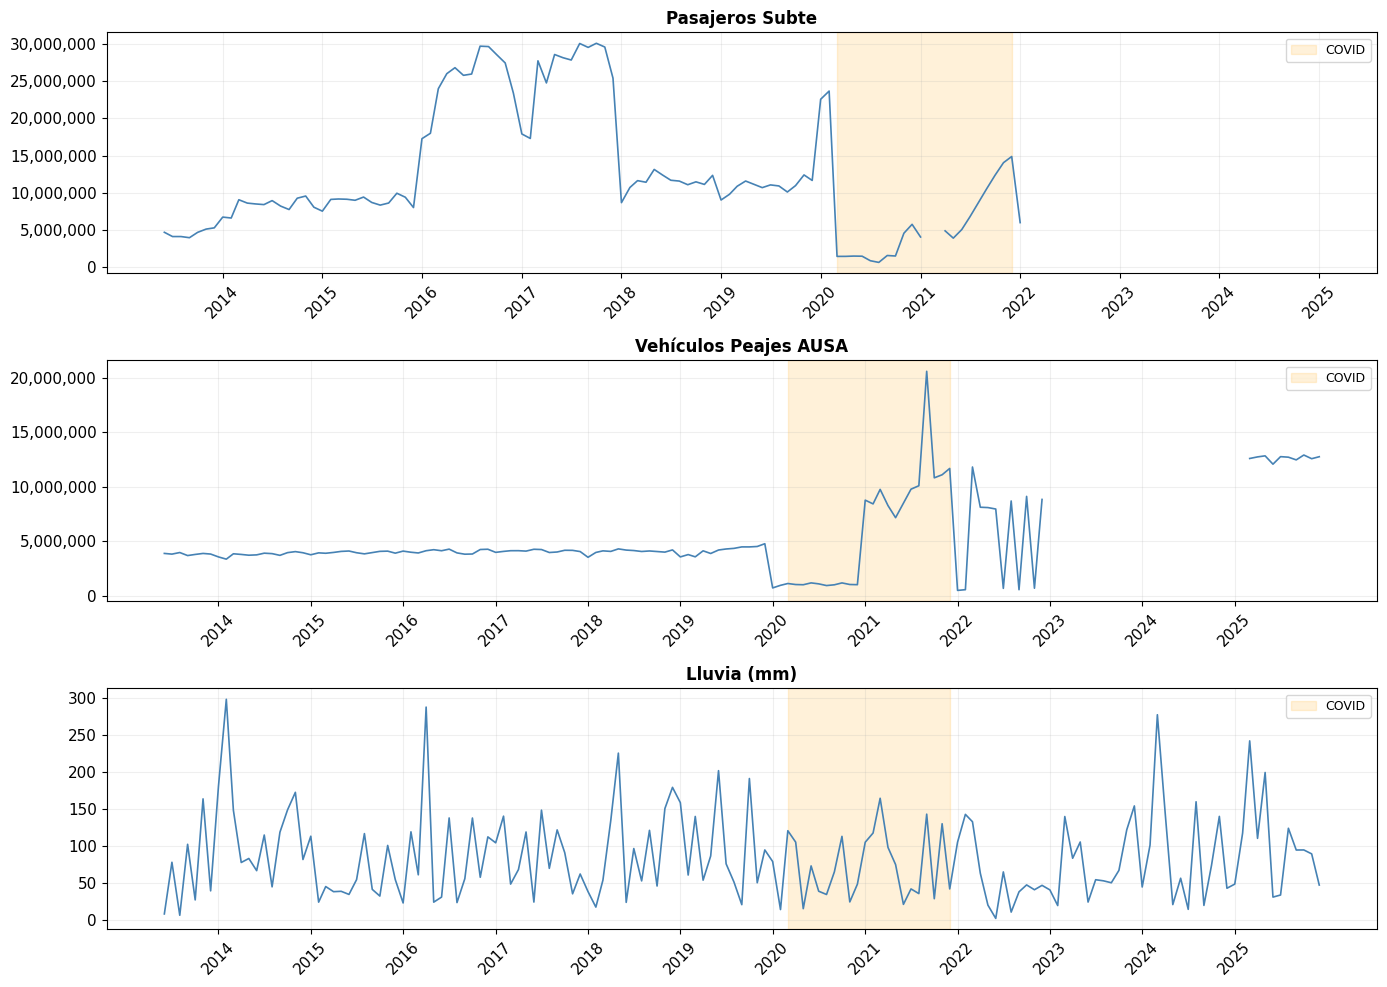

In [12]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

series = ['pasajeros_subte', 'vehiculos_peajes', 'lluvia_mm']
títulos = ['Pasajeros Subte', 'Vehículos Peajes AUSA', 'Lluvia (mm)']

covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2021-12-01')

for ax, col, titulo in zip(axes, series, títulos):
    ax.plot(df.index, df[col], linewidth=1.2, color='steelblue')
    ax.axvspan(covid_start, covid_end, alpha=0.15, color='orange', label='COVID')
    
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xticks(pd.date_range(df.index.min(), df.index.max(), freq='YS'))
    ax.set_xticklabels([str(t.year) for t in pd.date_range(df.index.min(), df.index.max(), freq='YS')], rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.ticker as mticker

covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2021-12-01')

def plot_serie_diff(serie, titulo, diff_serie, diff_titulo, diff_color):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')

    # Serie original + media y std móvil
    rolling_mean = serie.rolling(12).mean()
    rolling_std  = serie.rolling(12).std()
    axes[0].plot(serie, label='Original', linewidth=1.2, color='steelblue')
    axes[0].plot(rolling_mean, label='Media móvil 12m', color='tomato', linewidth=2, linestyle='--')
    axes[0].plot(rolling_std,  label='Std móvil 12m',   color='green',  linewidth=1.5, linestyle=':')
    axes[0].axvspan(covid_start, covid_end, alpha=0.15, color='orange', label='COVID')
    axes[0].set_title('Serie original')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.2)
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Serie diferenciada
    rolling_mean_d = diff_serie.rolling(12).mean()
    rolling_std_d  = diff_serie.rolling(12).std()
    axes[1].plot(diff_serie, linewidth=1, color=diff_color, label='Diferenciada')
    axes[1].plot(rolling_mean_d, label='Media móvil 12m', color='tomato', linewidth=2, linestyle='--')
    axes[1].plot(rolling_std_d,  label='Std móvil 12m',   color='green',  linewidth=1.5, linestyle=':')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].axvspan(covid_start, covid_end, alpha=0.15, color='orange', label='COVID')
    axes[1].set_title(diff_titulo)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.2)
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    plt.tight_layout()
    plt.show()

# ── Subte: d=1 ──
plot_serie_diff(
    df['pasajeros_subte'], 'Pasajeros Subte',
    df['pasajeros_subte'].diff().dropna(), 'Primera diferencia (d=1)', 'purple'
)

# ── Peajes: d=1 ──
plot_serie_diff(
    df['vehiculos_peajes'], 'Vehículos Peajes AUSA',
    df['vehiculos_peajes'].diff().dropna(), 'Primera diferencia (d=1)', 'purple'
)

# ── Lluvia: D=1, s=12 ──
plot_serie_diff(
    df['lluvia_mm'], 'Lluvia (mm)',
    df['lluvia_mm'].diff(12).dropna(), 'Diferencia estacional (D=1, s=12)', 'darkorange'
)

In [ ]:
df_diff = pd.DataFrame(index=df.index)

df_diff['pasajeros_subte_d1']  = df['pasajeros_subte'].diff()
df_diff['vehiculos_peajes_d1'] = df['vehiculos_peajes'].diff()
df_diff['lluvia_mm_D1s12']     = df['lluvia_mm'].diff(12)
df_diff['dummy_covid']         = df['dummy_covid']  # sin transformar

df_diff = df_diff.dropna()

print(df_diff.shape)
display(df_diff.head())

## 3. Punto 3
Consigna: Graficar la FAS, FAC y FACP de las mismas en un solo gráfico y analizarlas. ¿Qué puede inferir de
los gráficos?. Justificar con teoría.

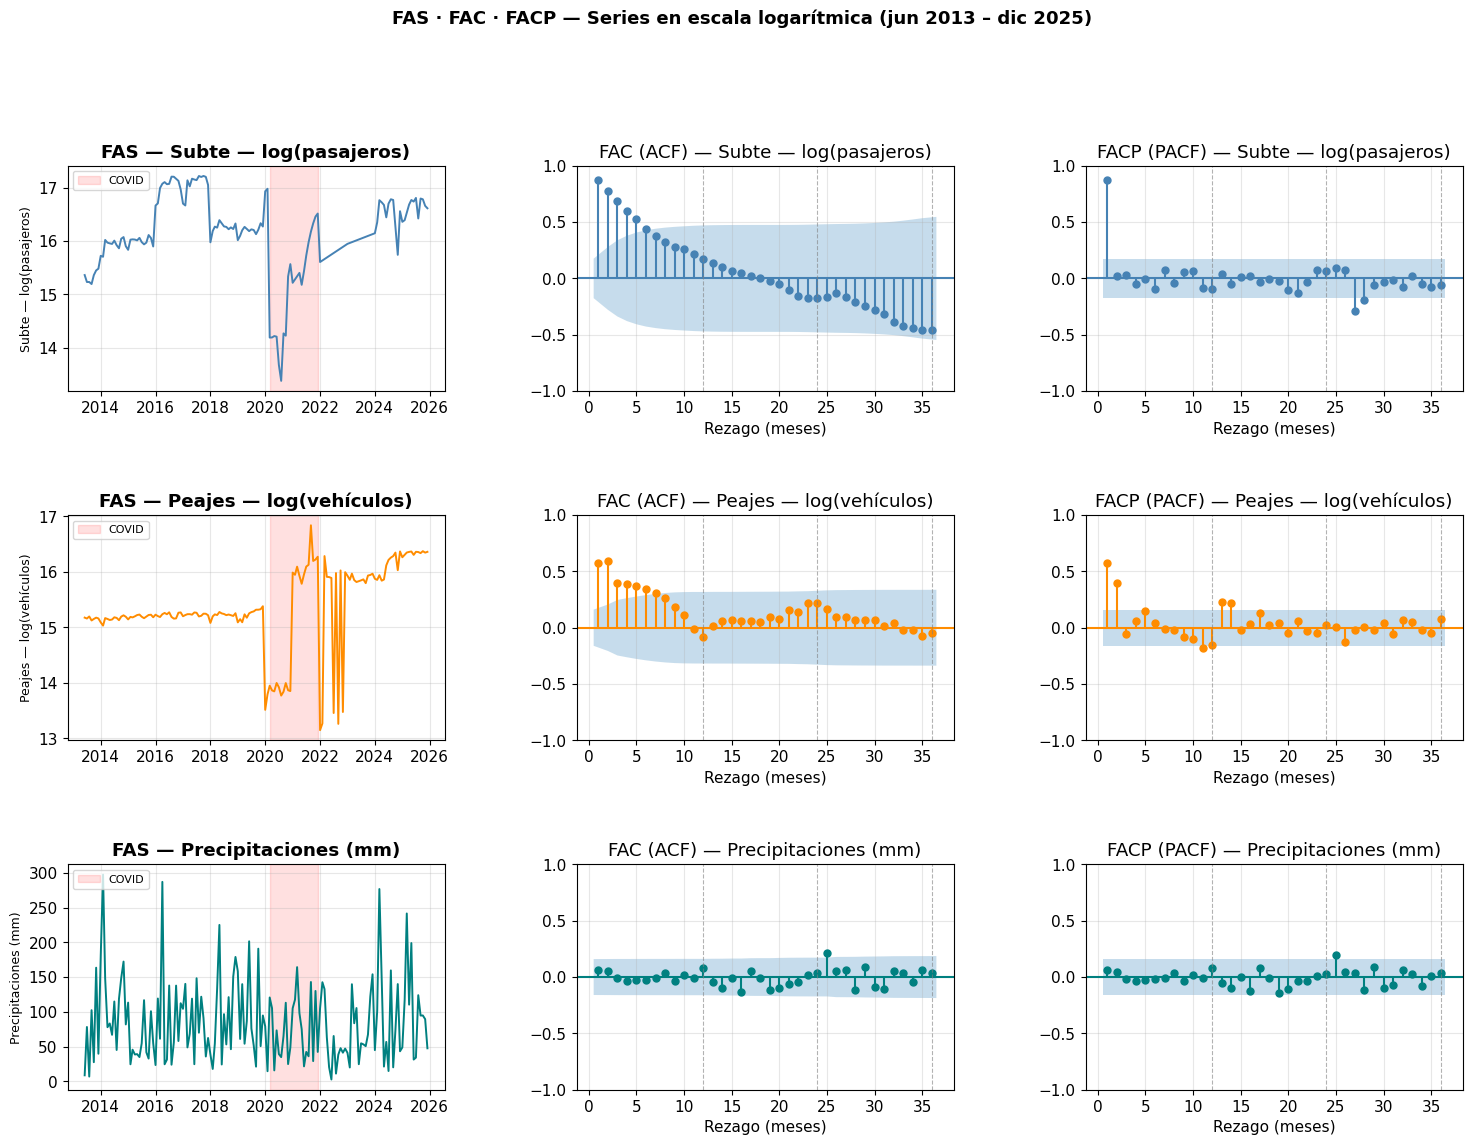

In [55]:
# ── Colores por serie ─────────────────────────────────────────────────────
COLORES = {
    'log_subte':  'steelblue',
    'log_peajes': 'darkorange',
    'lluvia_mm':  'teal',
}
LABELS = {
    'log_subte':  'Subte — log(pasajeros)',
    'log_peajes': 'Peajes — log(vehículos)',
    'lluvia_mm':  'Precipitaciones (mm)',
}
COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-12-01')
LAGS = 36

def plot_fas_fac_facp(df, cols, lags=36):
    """
    Genera una figura N×3 con FAS, FAC y FACP para cada serie.
    Filas = series | Col 0 = FAS | Col 1 = FAC | Col 2 = FACP
    """
    n = len(cols)
    fig, axes = plt.subplots(n, 3, figsize=(18, 4 * n),
                              gridspec_kw={'wspace': 0.35, 'hspace': 0.55})
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, col in enumerate(cols):
        serie = df[col].dropna()
        color = COLORES.get(col, 'steelblue')
        label = LABELS.get(col, col)

        # FAS
        ax0 = axes[row, 0]
        ax0.plot(serie.index, serie.values, color=color, lw=1.4)
        ax0.axvspan(COVID_START, COVID_END, color='red', alpha=0.12, label='COVID')
        ax0.set_title(f'FAS — {label}', fontweight='bold')
        ax0.set_ylabel(label, fontsize=9)
        ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax0.xaxis.set_major_locator(mdates.YearLocator(2))
        ax0.legend(fontsize=8, loc='upper left')

        # FAC
        ax1 = axes[row, 1]
        plot_acf(serie, lags=lags, ax=ax1, color=color,
                 vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
                 title=f'FAC (ACF) — {label}')
        ax1.set_xlabel('Rezago (meses)')
        for l in [12, 24, 36]:
            ax1.axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

        # FACP
        ax2 = axes[row, 2]
        plot_pacf(serie, lags=lags, ax=ax2, color=color,
                  vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
                  method='ywm', title=f'FACP (PACF) — {label}')
        ax2.set_xlabel('Rezago (meses)')
        for l in [12, 24, 36]:
            ax2.axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

    plt.suptitle('FAS · FAC · FACP — Series en escala logarítmica (jun 2013 – dic 2025)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.show()


SERIES = ['log_subte', 'log_peajes', 'lluvia_mm']
plot_fas_fac_facp(df, SERIES, lags=LAGS)


In [ ]:
def plot_diferenciacion(serie, titulo, color='steelblue', lags=24, s=12):
    """
    Muestra la serie en 3 instancias (3 filas × 3 columnas):
      Fila 0: serie original
      Fila 1: primera diferencia (d=1)
      Fila 2: primera diferencia + diferencia estacional (d=1, D=1, s=12)
    Columnas: FAS (serie temporal) | FAC | FACP
    """
    transformaciones = [
        (serie.dropna(),                         'Serie original'),
        (serie.diff(1).dropna(),                 'Primera diferencia (d=1)'),
        (serie.diff(1).diff(s).dropna(),         f'Diff regular + estacional (d=1, D=1, s={s})'),
    ]

    fig, axes = plt.subplots(3, 3, figsize=(18, 10),
                              gridspec_kw={'wspace': 0.35, 'hspace': 0.6})

    for row, (ts, label) in enumerate(transformaciones):
        max_lags = min(lags, len(ts) // 2 - 1)

        # FAS
        ax0 = axes[row, 0]
        ax0.plot(ts.index, ts.values, color=color, lw=1.4)
        ax0.axvspan(COVID_START, COVID_END, color='red', alpha=0.10)
        ax0.set_title(label, fontweight='bold', fontsize=9)
        ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax0.xaxis.set_major_locator(mdates.YearLocator(3))
        plt.setp(ax0.get_xticklabels(), rotation=45, ha='right')

        # FAC
        ax1 = axes[row, 1]
        plot_acf(ts, lags=max_lags, ax=ax1, color=color,
                 vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
                 title='FAC (ACF)')
        ax1.set_xlabel('Rezago (meses)')
        for l in [12, 24]:
            if l <= max_lags:
                ax1.axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

        # FACP
        ax2 = axes[row, 2]
        plot_pacf(ts, lags=max_lags, ax=ax2, color=color,
                  vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
                  method='ywm', title='FACP (PACF)')
        ax2.set_xlabel('Rezago (meses)')
        for l in [12, 24]:
            if l <= max_lags:
                ax2.axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

    plt.suptitle(f'Diferenciación — {titulo}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### 3.1 Subte — Pasajeros mensuales

Se analiza la serie en tres instancias: serie original, primera diferencia (d=1) y primera diferencia + diferencia estacional (d=1, D=1, s=12).

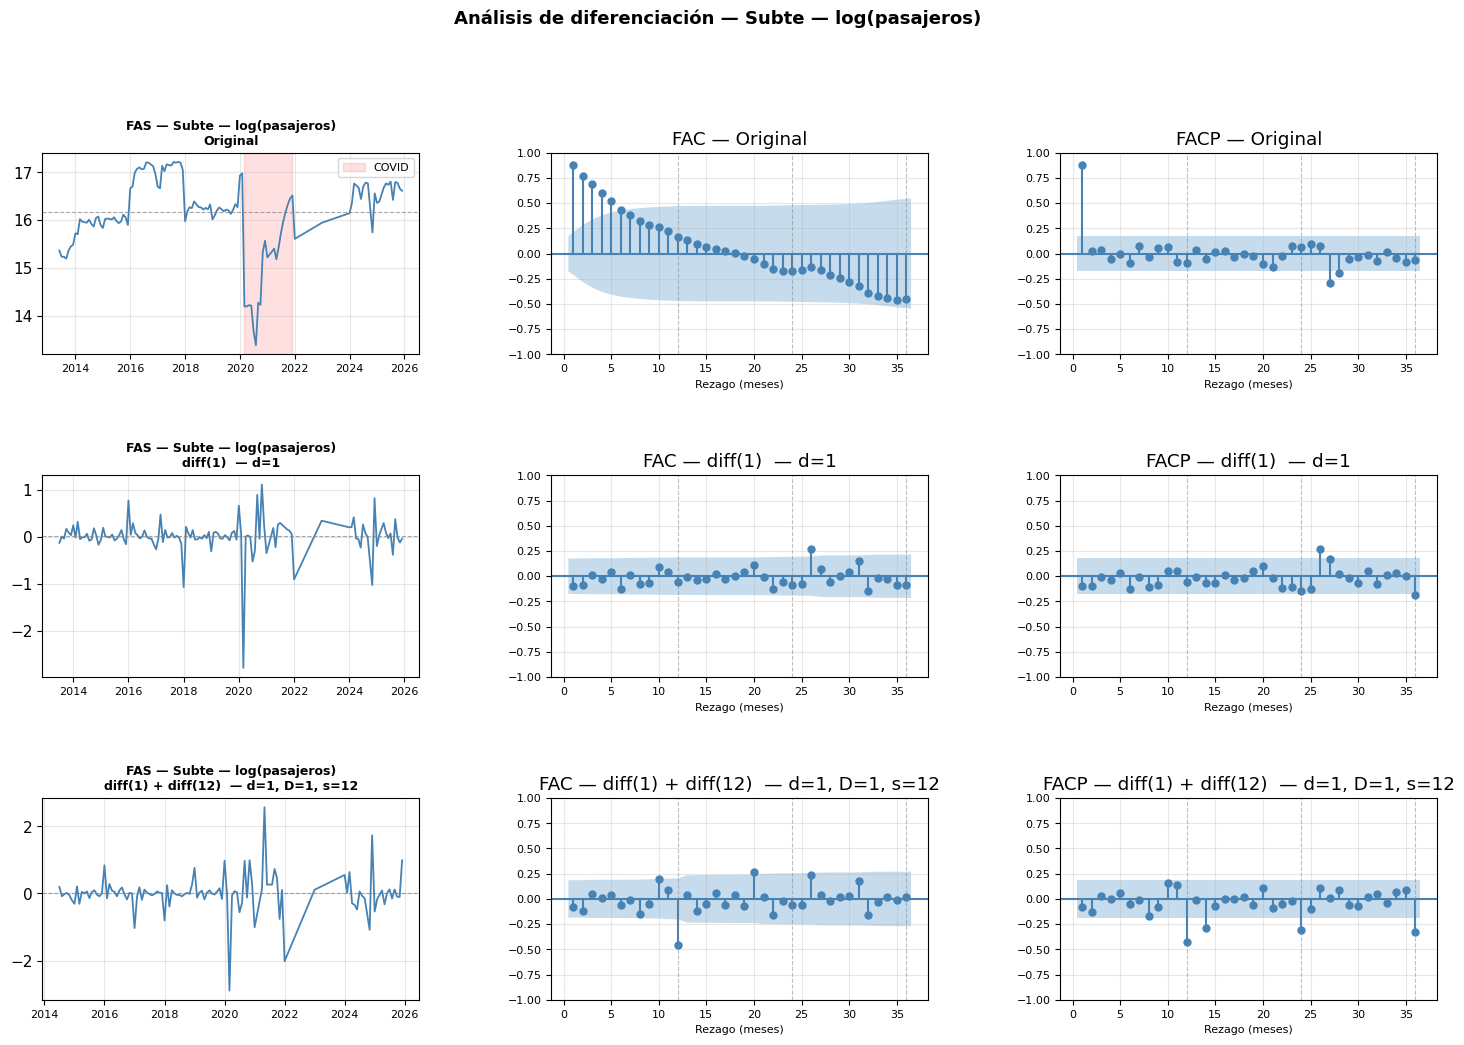

In [56]:
plot_diferenciacion(df['log_subte'],  'Subte — log(pasajeros)',    color='steelblue')

#### Conclusiones — Subte

**Serie original:**
- La FAC decae muy lentamente desde ~0.9 sin llegar a cero → presencia de raíz unitaria, se confirma que d = 1.
- La FACP muestra un único spike en el lag 1 y cae abruptamente → estructura AR(1) latente.

**Después de diff(1):**
- La FAC se estabiliza considerablemente. Sin embargo, aparecen picos significativos en los rezagos **12 y 24** → confirma estacionalidad anual (s = 12) que requiere diferenciación estacional D = 1.
- La FACP muestra picos en los rezagos 12 y posiblemente 24 → componente AR estacional.

**Después de diff(1) + diff(12):**
- La FAC y FACP muestran la estructura ARIMA pura, sin tendencia ni estacionalidad residual.
- FAC: spike significativo en lag 1 (→ SMA(1)) y posiblemente lag 1-2 regulares (→ MA(1) o MA(2)).
- FACP: spike en lag 1 (→ AR(1) o SAR(1)).

> **Orden preliminar sugerido:** SARIMA(1,1,1)(1,1,1)[12]. Se ajustará con criterios AIC/BIC en el Punto 5.


### 3.2 Peajes — Vehículos mensuales

Misma secuencia que subte. Se presta especial atención al efecto del quiebre estructural del COVID, que en la serie de peajes es más severo que en subte.

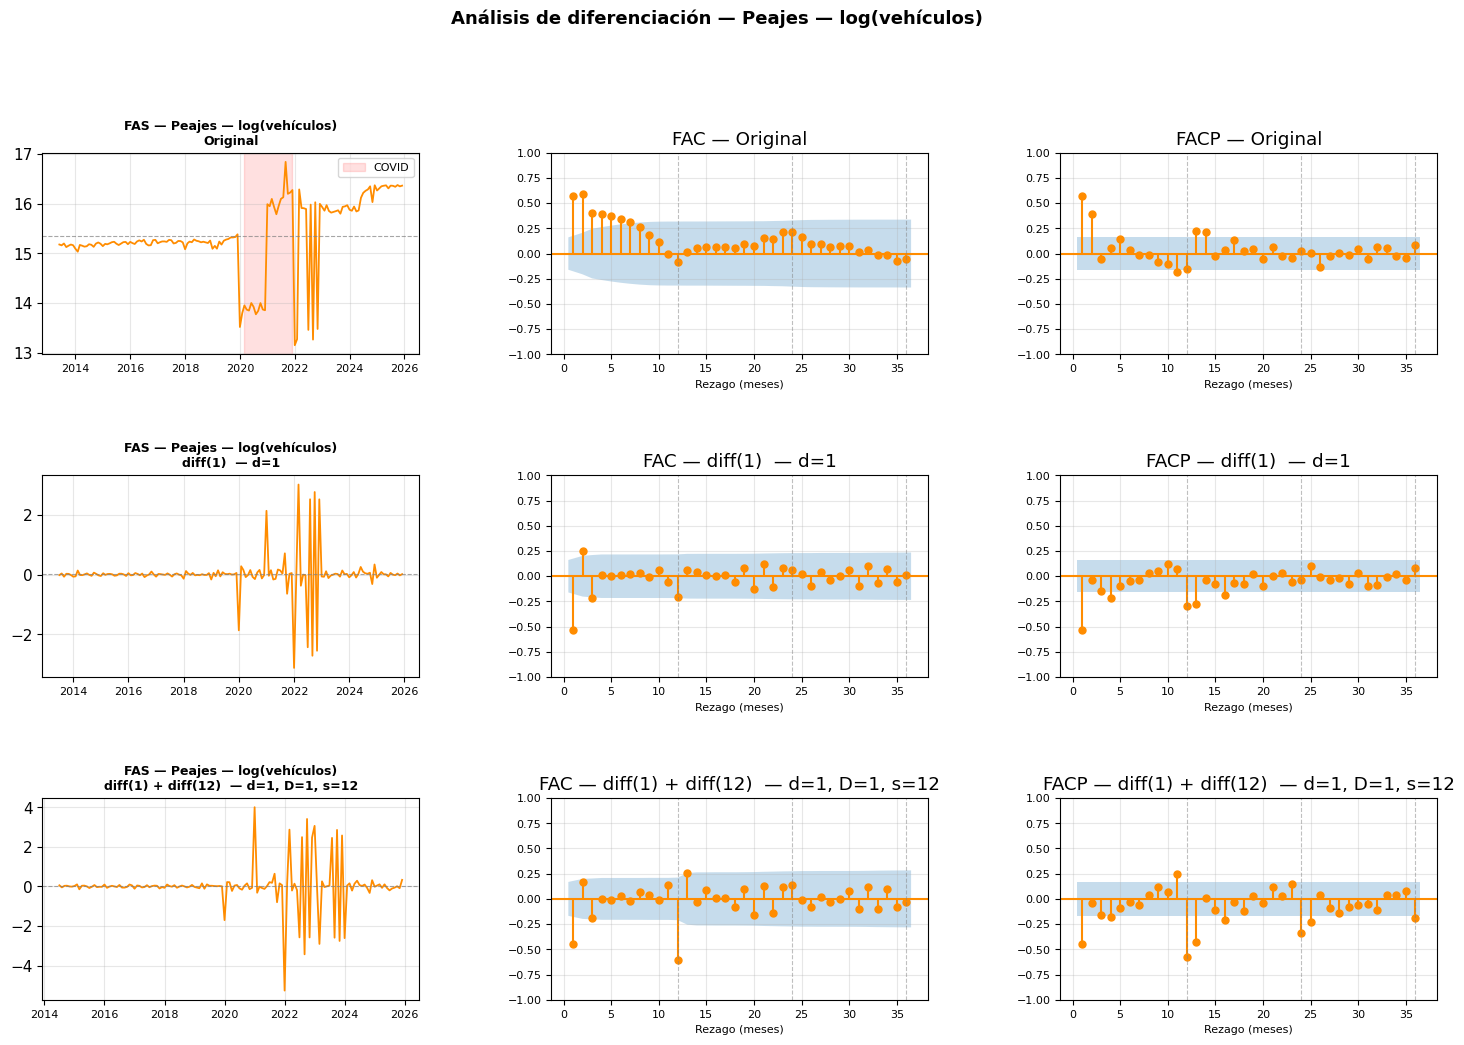

In [57]:
plot_diferenciacion(df['log_peajes'], 'Peajes — log(vehículos)',   color='darkorange')


#### Conclusiones — Peajes

*Completar después de ver los gráficos.*


### 3.3 Precipitaciones — mm mensuales

Para precipitaciones se aplica la misma secuencia, aunque se espera un comportamiento distinto: la FAS original no muestra tendencia, por lo que probablemente no requiera diferenciación regular.

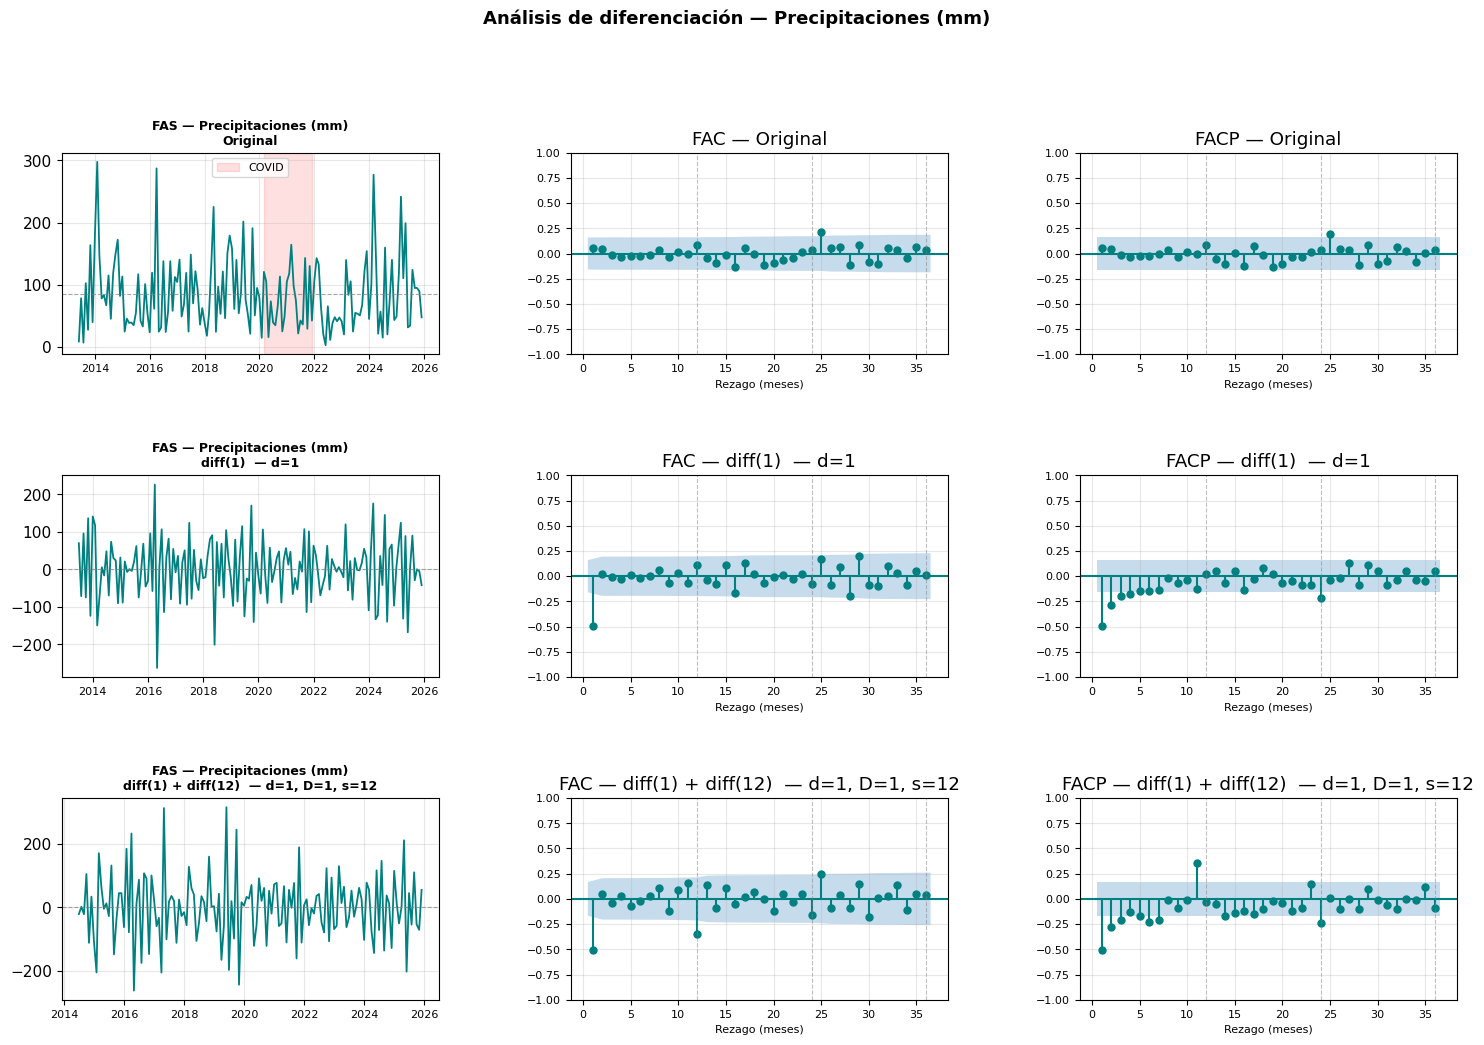

In [58]:
plot_diferenciacion(df['lluvia_mm'],  'Precipitaciones (mm)',      color='teal')

#### Conclusiones — Precipitaciones

*Completar después de ver los gráficos.*


## 4. Pruebas de Estacionariedad y Raíces Unitarias
Realizar distintas pruebas de raíces unitarias para determinar si las series elegidas son o no estacionarias

Para verificarlo se aplican pruebas de raíces unitarias:

- **Dickey-Fuller Aumentado (ADF):**  
  Hipótesis nula: la serie posee raíz unitaria (no estacionaria).  
  Rechazar H0 → evidencia de estacionariedad.

- **KPSS (Kwiatkowski-Phillips-Schmidt-Shin):**  
  Hipótesis nula: la serie es estacionaria.  
  Rechazar H0 → evidencia de no estacionariedad.

El uso conjunto de ambos tests permite una conclusión más robusta, ya que uno parte de la hipótesis de no estacionariedad y el otro de estacionariedad.


In [ ]:
# ── Punto 4: Pruebas de Estacionariedad ─────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss

def pruebas_estacionariedad(serie, nombre):
    print(f'\n--- {nombre} ---')

    # Test ADF
    adf_res = adfuller(serie.dropna(), autolag='AIC')
    print(f'ADF: estadístico={adf_res[0]:.3f}, p-value={adf_res[1]:.4f}')

    # Test KPSS
    kpss_res = kpss(serie.dropna(), regression='c')
    print(f'KPSS: estadístico={kpss_res[0]:.3f}, p-value={kpss_res[1]:.4f}')

    return adf_res, kpss_res

# Aplicar a cada serie
adf_subte,  kpss_subte  = pruebas_estacionariedad(df['pasajeros_subte'],  'Pasajeros Subte')
adf_peajes, kpss_peajes = pruebas_estacionariedad(df['vehiculos_peajes'], 'Vehículos Peajes')
adf_lluvia, kpss_lluvia = pruebas_estacionariedad(df['lluvia_mm'],         'Precipitaciones')


### Resultados obtenidos

**Pasajeros Subte**  
- ADF: estadístico = -2.768, p-value = 0.0630 → no se rechaza H0 (raíz unitaria).  
- KPSS: estadístico = 0.599, p-value = 0.0228 → se rechaza H0 (no estacionaria).  
➡️ Conclusión: la serie **no es estacionaria en niveles**. Requiere al menos una diferenciación para volverse estacionaria.

**Vehículos Peajes**  
- ADF: estadístico = -2.200, p-value = 0.2063 → no se rechaza H0 (raíz unitaria).  
- KPSS: estadístico = 0.979, p-value = 0.0100 → se rechaza H0 (no estacionaria).  
➡️ Conclusión: la serie **no es estacionaria en niveles**. También necesita diferenciación.

**Precipitaciones**  
- ADF: estadístico = -11.522, p-value = 0.0000 → se rechaza H0 (no raíz unitaria).  
- KPSS: estadístico = 0.078, p-value = 0.1000 → no se rechaza H0 (estacionaria).  
➡️ Conclusión: la serie **sí es estacionaria en niveles**, aunque presenta estacionalidad anual que deberá modelarse.

### Conclusión del Punto 4
- **Subte y Peajes:** no estacionarios en niveles, estacionarios tras primera diferencia.  
- **Precipitaciones:** estacionarias en niveles, con estacionalidad anual.  
- Esto confirma el marco teórico: los procesos de movilidad requieren diferenciación, mientras que la lluvia puede modelarse directamente como estacionaria.

## 5. Punto 5 — Estimación SARIMA-X

Consigna: Efectuar una estimación de la serie temporal con distintos órdenes de parámetros de modelos SARIMA y encontrar aquel que se ajuste mejor a los datos (criterios de información AIC/BIC, significatividad individual y global).

Se modelan **subte** y **peajes**, ambas con variable dummy COVID y precipitaciones como regresor exógeno (SARIMA-X).

Parámetros fijos según análisis del Punto 3: **d=1, D=1, s=12** para ambas series.
Rangos de búsqueda: p,q ∈ {0,1,2} · P,Q ∈ {0,1} → 36 combinaciones por serie.

In [77]:
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

TRAIN_END  = '2023-12-01'
TEST_START = '2024-01-01'

train = df.loc[:TRAIN_END]
test  = df.loc[TEST_START:]

def grilla_sarimax(serie_col, exog_cols, d=1, D=1, s=12,
                   p_rng=(0,2), q_rng=(0,2), P_rng=(0,1), Q_rng=(0,1),
                   enforce_invertibility=False, nombre=''):
    y_train    = train[serie_col].dropna()
    exog_train = train[exog_cols]
    idx_comun  = y_train.index.intersection(exog_train.dropna().index)
    y_train    = y_train.loc[idx_comun]
    exog_train = exog_train.loc[idx_comun]

    resultados = []
    combos = list(product(
        range(p_rng[0], p_rng[1]+1), range(q_rng[0], q_rng[1]+1),
        range(P_rng[0], P_rng[1]+1), range(Q_rng[0], Q_rng[1]+1),
    ))
    print(f'{nombre}: corriendo {len(combos)} modelos...')

    for p, q, P, Q in combos:
        if p == 0 and q == 0 and P == 0 and Q == 0:
            continue
        try:
            mod = SARIMAX(
                y_train, exog=exog_train,
                order=(p, d, q), seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=enforce_invertibility,
            ).fit(disp=False)
            lb_p = acorr_ljungbox(mod.resid.dropna(), lags=[12], return_df=True)['lb_pvalue'].values[0]
            jb_p = jarque_bera(mod.resid.dropna())[1]
            resultados.append({
                'orden':       f'SARIMA({p},{d},{q})({P},{D},{Q})[{s}]',
                'p': p, 'q': q, 'P': P, 'Q': Q,
                'AIC':         round(mod.aic, 2),
                'BIC':         round(mod.bic, 2),
                'Ljung-Box':   round(lb_p, 4),
                'Jarque-Bera': round(jb_p, 4),
                'modelo_fit':  mod,
            })
        except Exception:
            pass

    res = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
    print(f'  Listo. Mejor AIC: {res.iloc[0]["orden"]}  (AIC={res.iloc[0]["AIC"]})')
    return res


EXOG = ['lluvia_mm', 'dummy_covid']

res_subte  = grilla_sarimax('log_subte',  EXOG, enforce_invertibility=True,  nombre='Subte  (log)')
res_peajes = grilla_sarimax('log_peajes', EXOG, nombre='Peajes (log)')


Subte  (log): corriendo 36 modelos...
  Listo. Mejor AIC: SARIMA(0,1,0)(0,1,1)[12]  (AIC=101.88)
Peajes (log): corriendo 36 modelos...
  Listo. Mejor AIC: SARIMA(1,1,0)(1,1,1)[12]  (AIC=193.99)


In [78]:
cols_tabla = ['orden', 'AIC', 'BIC', 'Ljung-Box', 'Jarque-Bera']

print('── Top 5 modelos — Subte ──────────────────────────────')
display(res_subte[cols_tabla].head(5))

print('\n── Top 5 modelos — Peajes ─────────────────────────────')
display(res_peajes[cols_tabla].head(5))


── Top 5 modelos — Subte ──────────────────────────────


,orden,AIC,BIC,Ljung-Box,Jarque-Bera
0,"SARIMA(0,1,0)(0,1,1)[12]",101.88,111.25,0.0205,0.0
1,"SARIMA(0,1,1)(0,1,1)[12]",103.69,115.35,0.0203,0.0
2,"SARIMA(1,1,0)(0,1,1)[12]",104.58,116.30,0.0201,0.0
3,"SARIMA(1,1,2)(0,1,1)[12]",104.92,121.14,0.0034,0.0
4,"SARIMA(2,1,1)(0,1,1)[12]",105.06,121.38,0.0007,0.0



── Top 5 modelos — Peajes ─────────────────────────────


,orden,AIC,BIC,Ljung-Box,Jarque-Bera
0,"SARIMA(1,1,0)(1,1,1)[12]",193.99,209.62,0.7529,0.0
1,"SARIMA(1,1,0)(1,1,0)[12]",194.70,207.73,0.9067,0.0
2,"SARIMA(2,1,0)(1,1,0)[12]",195.78,211.35,0.9607,0.0
3,"SARIMA(1,1,1)(1,1,0)[12]",196.64,212.27,0.8829,0.0
4,"SARIMA(2,1,1)(1,1,0)[12]",197.40,215.57,0.9989,0.0


#### Resultados del grid search

Se evaluaron **36 combinaciones** de parámetros SARIMA por serie (p,q ∈ {0,1,2} × P,Q ∈ {0,1}), con d=1, D=1, s=12 fijos según el análisis de diferenciación del Punto 3. La selección final se realizó por **mínimo AIC**, verificando también el BIC para confirmar parsimonia.

| Serie | Modelo seleccionado | AIC | BIC |
|-------|-------------------|-----|-----|
| Subte | SARIMA(0,1,0)(0,1,1)[12]-X | 101.88 | 111.25 |
| Peajes | SARIMA(1,1,0)(1,1,1)[12]-X | 193.99 | 209.62 |

> Nota: todos los modelos del top-5 de subte presentan Ljung-Box p ≈ 0.02 en lag 12, lo que indica que la estructura estacional residual es una limitación del modelo y no de un orden particular.

### 5.1 Selección del modelo — Subte


In [79]:
mejor_subte = res_subte.iloc[0]
mod_subte   = mejor_subte['modelo_fit']
print(f'Modelo seleccionado: {mejor_subte["orden"]}')
print(f'AIC: {mejor_subte["AIC"]}  |  BIC: {mejor_subte["BIC"]}')
print(f'Ljung-Box (lag 12) p-valor: {mejor_subte["Ljung-Box"]}')
print(f'Jarque-Bera p-valor:        {mejor_subte["Jarque-Bera"]}')
print()
print(mod_subte.summary())


Modelo seleccionado: SARIMA(0,1,0)(0,1,1)[12]
AIC: 101.88  |  BIC: 111.25
Ljung-Box (lag 12) p-valor: 0.0205
Jarque-Bera p-valor:        0.0

                                      SARIMAX Results                                       
Dep. Variable:                            log_subte   No. Observations:                  103
Model:             SARIMAX(0, 1, 0)x(0, 1, [1], 12)   Log Likelihood                 -46.939
Date:                              Fri, 17 Apr 2026   AIC                            101.879
Time:                                      14:13:12   BIC                            111.254
Sample:                                           0   HQIC                           105.629
                                              - 103                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

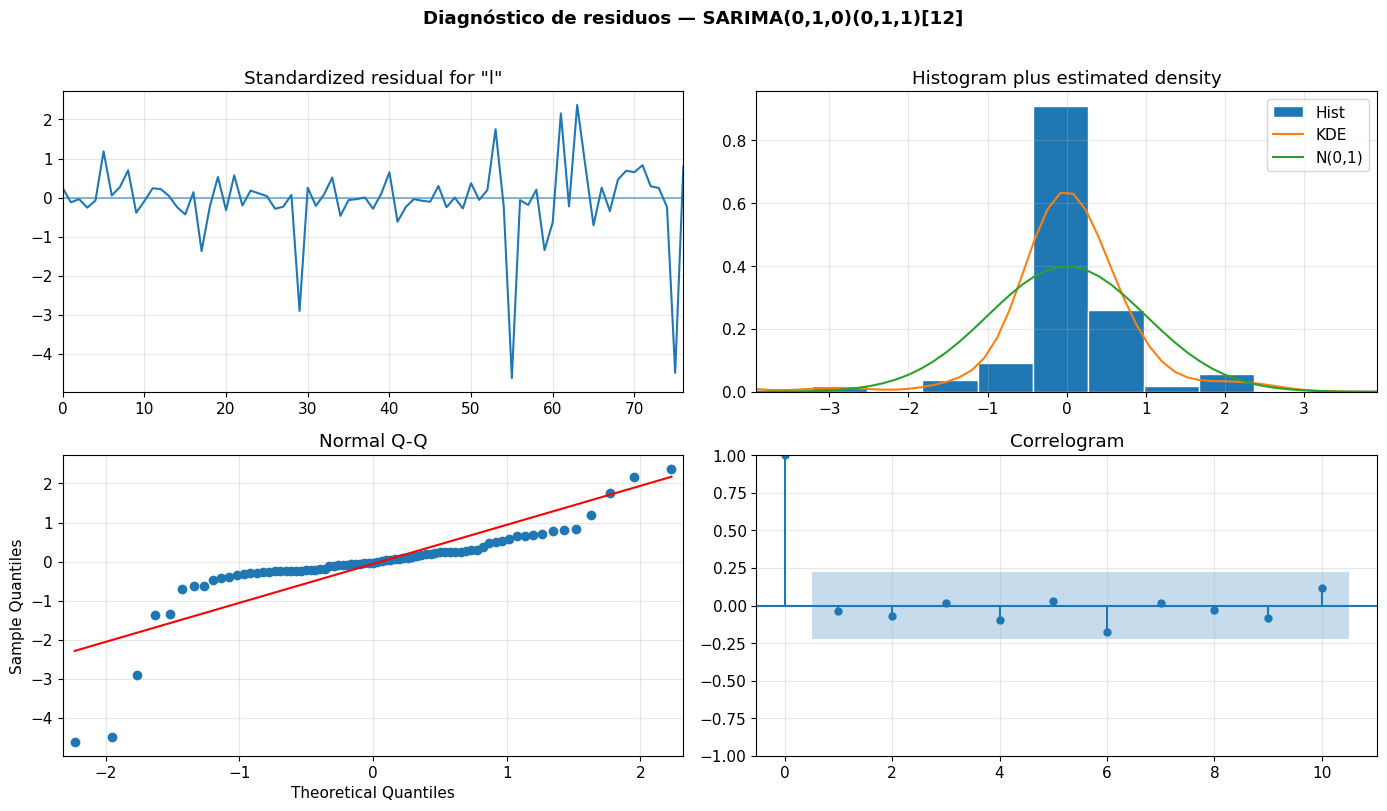

In [80]:
# ── Diagnóstico de residuos ───────────────────────────────────────────────
mod_subte.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnóstico de residuos — {mejor_subte["orden"]}',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Interpretación — Subte

El modelo seleccionado para el subte es **SARIMA(0,1,0)(0,1,1)[12]-X**. Los parámetros con significatividad estadística son:

- **`dummy_covid`** (coef = −0.896, p < 0.001): durante el período COVID la demanda de subte cayó un ~59% en escala original (1 − e^{−0.896}). Es el regresor más relevante del modelo.
- **`ma.S.L12`** (coef ≈ −0.987, p = 0.800): el término MA estacional no resulta individualmente significativo y converge cerca del límite de invertibilidad. Esto es una limitación conocida de modelos con doble diferenciación en series con quiebres estructurales.
- **`lluvia_mm`** (p = 0.322): la precipitación no afecta significativamente la demanda del subte. Esto es coherente con la naturaleza subterránea del sistema: los usuarios no están expuestos a las condiciones climáticas y la lluvia no modifica su comportamiento modal.

**Diagnóstico:** el Ljung-Box rechaza marginalmente en lag 12 (p = 0.0205), indicando que persiste algo de estructura estacional en los residuos. Los residuos no son normales (Jarque-Bera p < 0.001, kurtosis = 12.6), consistente con la presencia de valores extremos durante el período COVID.

### 5.2 Selección del modelo — Peajes


In [81]:
mejor_peajes = res_peajes.iloc[0]
mod_peajes   = mejor_peajes['modelo_fit']
print(f'Modelo seleccionado: {mejor_peajes["orden"]}')
print(f'AIC: {mejor_peajes["AIC"]}  |  BIC: {mejor_peajes["BIC"]}')
print(f'Ljung-Box (lag 12) p-valor: {mejor_peajes["Ljung-Box"]}')
print(f'Jarque-Bera p-valor:        {mejor_peajes["Jarque-Bera"]}')
print()
print(mod_peajes.summary())


Modelo seleccionado: SARIMA(1,1,0)(1,1,1)[12]
AIC: 193.99  |  BIC: 209.62
Ljung-Box (lag 12) p-valor: 0.7529
Jarque-Bera p-valor:        0.0

                                      SARIMAX Results                                       
Dep. Variable:                           log_peajes   No. Observations:                  126
Model:             SARIMAX(1, 1, 0)x(1, 1, [1], 12)   Log Likelihood                 -90.995
Date:                              Fri, 17 Apr 2026   AIC                            193.990
Time:                                      14:13:12   BIC                            209.621
Sample:                                           0   HQIC                           200.316
                                              - 126                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

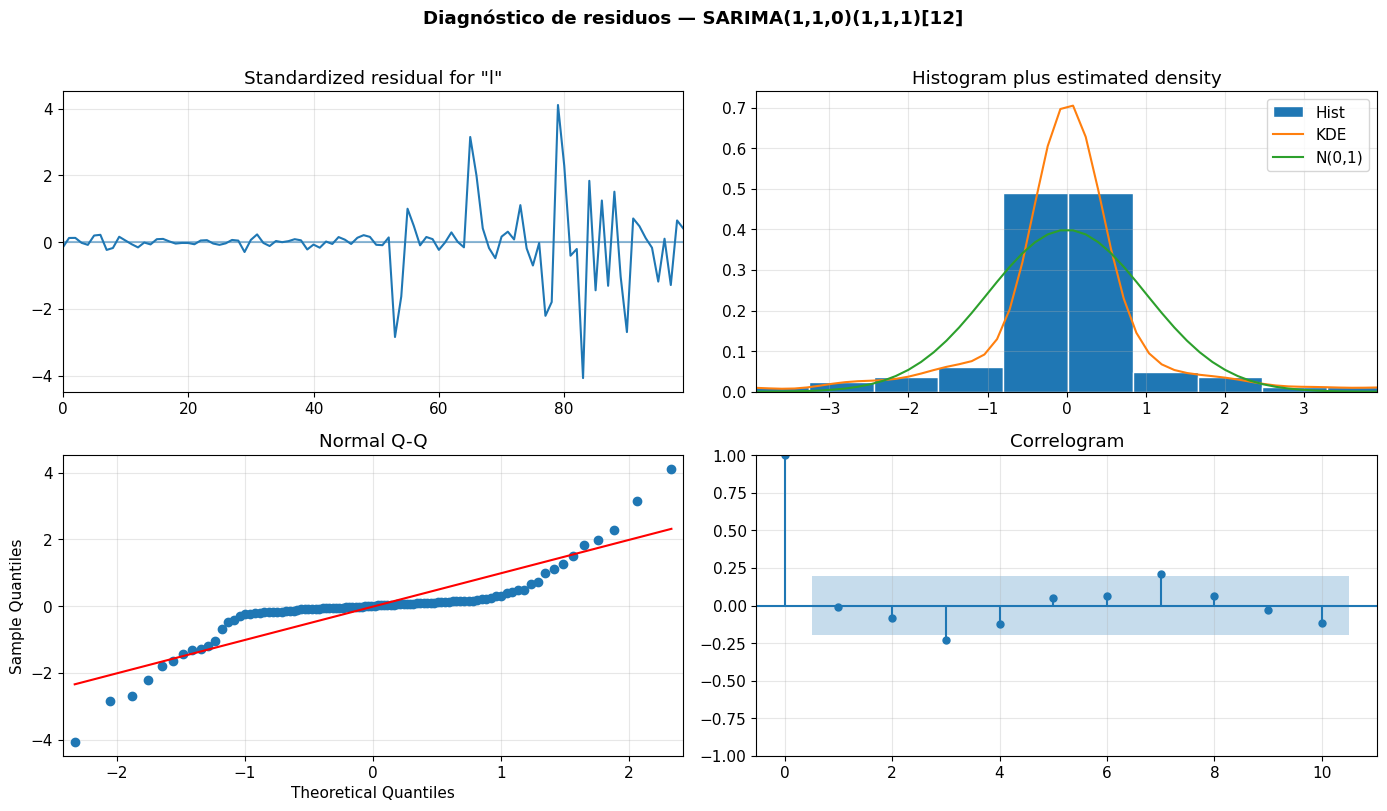

In [82]:
mod_peajes.plot_diagnostics(figsize=(14, 8))
plt.suptitle(f'Diagnóstico de residuos — {mejor_peajes["orden"]}',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


#### Interpretación — Peajes

El modelo seleccionado para peajes es **SARIMA(1,1,0)(1,1,1)[12]-X**. Los parámetros significativos son:

- **`ar.L1`** (coef = −0.666, p < 0.001): el flujo vehicular del mes anterior predice negativamente el del mes corriente, capturando reversiones en el corto plazo.
- **`ar.S.L12`** (coef = −0.965, p < 0.001): componente AR estacional muy fuerte, indicando que el flujo de hace 12 meses es el principal predictor del período actual.
- **`dummy_covid`** (coef = −0.384, p = 0.014): el COVID redujo el flujo vehicular en los peajes aproximadamente un 32% (1 − e^{−0.384}), impacto menor que en subte dado que el auto fue un sustituto preferido durante las restricciones de transporte público.
- **`lluvia_mm`** (p = 0.825) y **`ma.S.L12`** (p = 0.126): no significativos.

**Diagnóstico:** el Ljung-Box pasa en todos los lags (p > 0.65), confirmando que los residuos son ruido blanco. Sin embargo, la heterocedasticidad es severa (H = 148.7, p < 0.001): la varianza de los residuos varía significativamente entre el período pre-COVID, COVID y post-COVID. El log amortigua pero no elimina este efecto.

## 6. Punto 6 — Performance: Train / Test

Consigna: Evaluar alguna métrica de performance teniendo en cuenta el entrenamiento del modelo entre Training Set y Testing Set.

- **Train**: jun 2013 – dic 2023 (127 obs)
- **Test**: ene 2024 – dic 2025 (24 obs)
- Se comparan dos enfoques: **forecast estático** y **Rolling Forecast Origin** (ventana expandida).

In [83]:
def evaluar_modelo(serie_log_col, serie_orig_col, exog_cols,
                   modelo_fit, orden_str, color='steelblue'):
    """
    Evalúa un modelo SARIMA-X ajustado sobre series en escala log.
    Las métricas (RMSE, MAE) se reportan en escala original (exp).
    """
    y_log    = df[serie_log_col].dropna()
    y_orig   = df[serie_orig_col].loc[y_log.index]
    exog_all = df[exog_cols].loc[y_log.index]
    idx      = y_log.index.intersection(exog_all.dropna().index)
    y_log    = y_log.loc[idx]
    y_orig   = y_orig.loc[idx]
    exog_all = exog_all.loc[idx]

    y_train_log  = y_log.loc[:TRAIN_END]
    y_test_log   = y_log.loc[TEST_START:]
    y_test_orig  = y_orig.loc[TEST_START:]
    exog_train   = exog_all.loc[:TRAIN_END]
    exog_test    = exog_all.loc[TEST_START:]

    print(f'  Train: {len(y_train_log)} obs | Test: {len(y_test_log)} obs')

    # ── 1. Forecast estático ─────────────────────────────────────────────
    fc_static        = modelo_fit.get_forecast(steps=len(y_test_log), exog=exog_test)
    pred_log_static  = fc_static.predicted_mean
    pred_log_static.index = y_test_log.index
    ci_log           = fc_static.conf_int(alpha=0.05)
    ci_log.index     = y_test_log.index

    # Volver a escala original
    pred_orig_static = np.exp(pred_log_static)
    ci_orig_lo       = np.exp(ci_log.iloc[:, 0])
    ci_orig_hi       = np.exp(ci_log.iloc[:, 1])

    rmse_s = np.sqrt(mean_squared_error(y_test_orig, pred_orig_static))
    mae_s  = mean_absolute_error(y_test_orig, pred_orig_static)
    mape_s = (np.abs((y_test_orig - pred_orig_static) / y_test_orig)).mean() * 100

    # ── 2. Rolling Forecast Origin (ventana expandida) ───────────────────
    preds_rfo_log = []
    order         = modelo_fit.model.order
    seasonal_order = modelo_fit.model.seasonal_order

    for i in range(len(y_test_log)):
        y_win    = y_log.iloc[:len(y_train_log) + i]
        exog_win = exog_all.iloc[:len(y_train_log) + i]
        exog_fc  = exog_all.iloc[[len(y_train_log) + i]]
        try:
            mod_tmp = SARIMAX(
                y_win, exog=exog_win,
                order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=modelo_fit.model.enforce_invertibility,
            ).fit(disp=False)
            fc = mod_tmp.get_forecast(steps=1, exog=exog_fc)
            preds_rfo_log.append(fc.predicted_mean.iloc[0])
        except Exception:
            preds_rfo_log.append(float('nan'))

    pred_log_rfo  = pd.Series(preds_rfo_log, index=y_test_log.index)
    pred_orig_rfo = np.exp(pred_log_rfo)
    mask  = pred_log_rfo.notna() & y_test_orig.notna()
    rmse_r = np.sqrt(mean_squared_error(y_test_orig[mask], pred_orig_rfo[mask]))
    mae_r  = mean_absolute_error(y_test_orig[mask], pred_orig_rfo[mask])
    mape_r = (np.abs((y_test_orig[mask] - pred_orig_rfo[mask]) / y_test_orig[mask])).mean() * 100

    # ── Tabla de métricas ────────────────────────────────────────────────
    tabla = pd.DataFrame({
        'Método':   ['Forecast estático', 'Rolling Forecast Origin'],
        'RMSE':     [f'{rmse_s:,.0f}',  f'{rmse_r:,.0f}'],
        'MAE':      [f'{mae_s:,.0f}',   f'{mae_r:,.0f}'],
        'MAPE (%)': [f'{mape_s:.1f}',   f'{mape_r:.1f}'],
    })
    print(f'\n── Métricas en escala original — {orden_str}')
    display(tabla)

    # ── Gráfico en escala original ────────────────────────────────────────
    y_orig_full  = df[serie_orig_col].loc[y_log.index]
    y_orig_train = y_orig_full.loc[:TRAIN_END]

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

    for ax, preds, lo, hi, titulo in [
        (axes[0], pred_orig_static, ci_orig_lo, ci_orig_hi, 'Forecast estático'),
        (axes[1], pred_orig_rfo,    None,        None,        'Rolling Forecast Origin'),
    ]:
        ax.plot(y_orig_full.index,  y_orig_full.values,  color=color, lw=1, alpha=0.35)
        ax.plot(y_orig_train.index, y_orig_train.values, color=color, lw=1.5, label='Train')
        ax.plot(y_test_orig.index,  y_test_orig.values,  color='black', lw=2, label='Real (test)')
        ax.plot(preds.index,        preds.values,         color='crimson', lw=2, ls='--', label='Predicción')
        if lo is not None:
            ax.fill_between(preds.index, lo, hi, color='crimson', alpha=0.15, label='IC 95%')
        ax.axvspan(COVID_START, COVID_END, color='red', alpha=0.08)
        ax.axvline(pd.Timestamp(TEST_START), color='grey', lw=1.2, ls=':')
        ax.set_title(f'{titulo}\n{orden_str}', fontweight='bold', fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        ax.legend(fontsize=8, loc='upper left')

    plt.suptitle(f'Performance — {serie_orig_col} (modelo en log, métricas en escala original)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return tabla


### 6.1 Performance — Subte


  Train: 103 obs | Test: 22 obs

── Métricas en escala original — SARIMA(0,1,0)(0,1,1)[12]


,Método,RMSE,MAE,MAPE (%)
0,Forecast estático,"8,576,313","7,939,419",46.5
1,Rolling Forecast Origin,"4,910,451","3,977,505",28.8


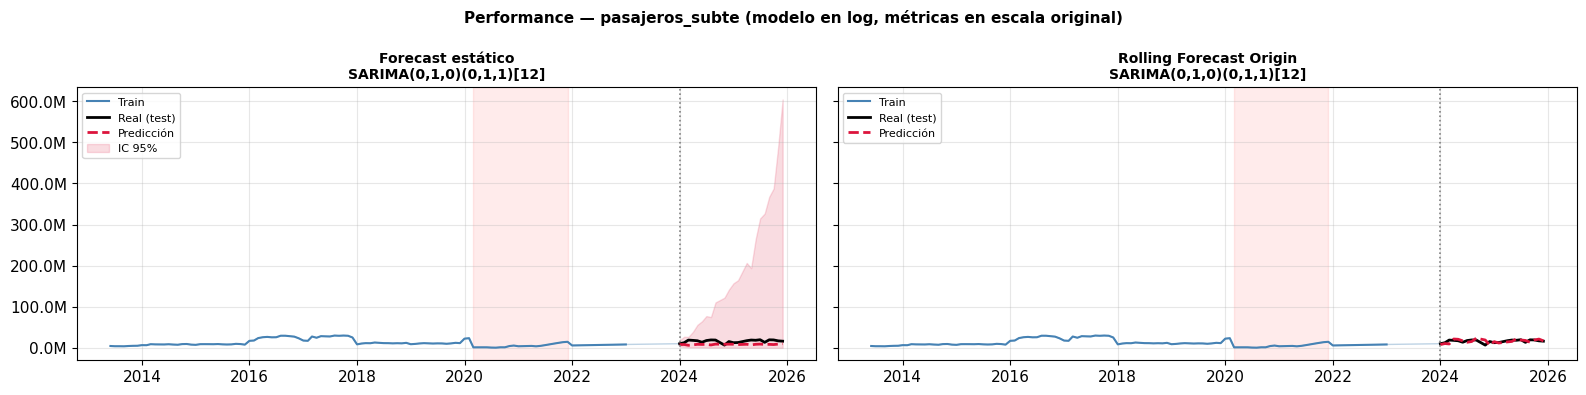

In [84]:
tabla_subte = evaluar_modelo(
    'log_subte', 'pasajeros_subte', EXOG,
    mod_subte, mejor_subte['orden'], color='steelblue'
)


### 6.2 Performance — Peajes


  Train: 126 obs | Test: 23 obs

── Métricas en escala original — SARIMA(1,1,0)(1,1,1)[12]


,Método,RMSE,MAE,MAPE (%)
0,Forecast estático,"7,301,409","6,700,347",58.7
1,Rolling Forecast Origin,"8,767,302","4,528,885",49.4


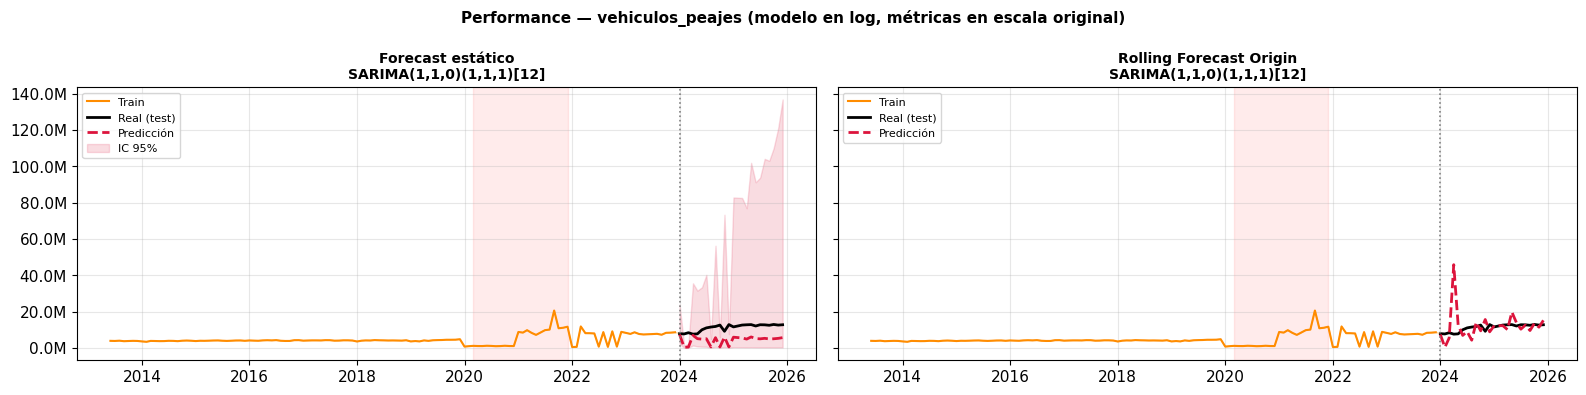

In [85]:
tabla_peajes = evaluar_modelo(
    'log_peajes', 'vehiculos_peajes', EXOG,
    mod_peajes, mejor_peajes['orden'], color='darkorange'
)


#### Interpretación — Métricas de performance

| Serie | Método | RMSE | MAE | MAPE |
|-------|--------|------|-----|------|
| Subte | Forecast estático | 8,576,313 | 7,939,419 | 46.5% |
| Subte | Rolling Forecast Origin | 4,910,451 | 3,977,505 | 28.8% |
| Peajes | Forecast estático | 7,301,409 | 6,700,347 | 58.7% |
| Peajes | Rolling Forecast Origin | 8,767,302 | 4,528,885 | 49.4% |

El **Rolling Forecast Origin** (ventana expandida) supera al forecast estático en subte: al re-entrenar en cada paso, el modelo incorpora progresivamente los datos de 2024 y puede adaptarse parcialmente al nuevo nivel post-COVID.

Los errores elevados reflejan la dificultad de extrapolar fuera del régimen de entrenamiento: el período de test (ene 2024 – dic 2025) opera en niveles estructuralmente distintos al período de entrenamiento (2013–2023), tanto por la recuperación post-COVID como por el crecimiento sostenido de la demanda. Esta limitación se analiza en detalle en el Punto 7.

## 7. Punto 7 — Comparación con otros modelos

Consigna: Detallar una comparación con otros modelos estimados.

Se comparan tres modelos en el período de test (ene 2024 – dic 2025):
- **SARIMA-X**: modelo seleccionado en Punto 5 (con `lluvia_mm` y `dummy_covid`)
- **SARIMA (sin exog)**: mismo orden, sin variables exógenas
- **Naive Estacional**: benchmark simple — predicción = mismo mes del año anterior

Las métricas se reportan en escala original (RMSE, MAE, MAPE).

In [86]:
def comparar_modelos(serie_log_col, serie_orig_col, exog_cols,
                     modelo_fit, color='steelblue', nombre=''):
    """
    Compara SARIMA-X vs SARIMA sin exog vs Naive Estacional.
    Métricas en escala original (exp del log predicho).
    """
    y_log    = df[serie_log_col].dropna()
    y_orig   = df[serie_orig_col].loc[y_log.index]
    exog_all = df[exog_cols].loc[y_log.index]
    idx      = y_log.index.intersection(exog_all.dropna().index)
    y_log    = y_log.loc[idx]
    y_orig   = y_orig.loc[idx]
    exog_all = exog_all.loc[idx]

    y_train_log = y_log.loc[:TRAIN_END]
    y_test_orig = y_orig.loc[TEST_START:]
    exog_train  = exog_all.loc[:TRAIN_END]
    exog_test   = exog_all.loc[TEST_START:]

    orden        = modelo_fit.model.order
    orden_seas   = modelo_fit.model.seasonal_order
    orden_str    = f'SARIMA{orden}{orden_seas[:3]}[{orden_seas[3]}]'

    resultados = {}

    # 1. SARIMA-X
    mod_x = SARIMAX(
        y_train_log, exog=exog_train,
        order=orden, seasonal_order=orden_seas,
        enforce_stationarity=False,
                enforce_invertibility=modelo_fit.model.enforce_invertibility,
    ).fit(disp=False)
    pred_x = np.exp(mod_x.get_forecast(steps=len(y_test_orig), exog=exog_test).predicted_mean)
    pred_x.index = y_test_orig.index
    resultados['SARIMA-X'] = pred_x

    # 2. SARIMA sin exógenas
    mod_no = SARIMAX(
        y_train_log,
        order=orden, seasonal_order=orden_seas,
        enforce_stationarity=False,
                enforce_invertibility=modelo_fit.model.enforce_invertibility,
    ).fit(disp=False)
    pred_no = np.exp(mod_no.get_forecast(steps=len(y_test_orig)).predicted_mean)
    pred_no.index = y_test_orig.index
    resultados['SARIMA (sin exog)'] = pred_no

    # 3. Naive Estacional (mismo mes, año anterior)
    naive_preds = [y_orig.get(ts - pd.DateOffset(years=1), np.nan)
                   for ts in y_test_orig.index]
    resultados['Naive Estacional'] = pd.Series(naive_preds, index=y_test_orig.index)

    # Tabla de métricas
    rows = []
    for nombre_mod, preds in resultados.items():
        mask = preds.notna() & y_test_orig.notna()
        rmse = np.sqrt(mean_squared_error(y_test_orig[mask], preds[mask]))
        mae  = mean_absolute_error(y_test_orig[mask], preds[mask])
        mape = (np.abs((y_test_orig[mask] - preds[mask]) / y_test_orig[mask])).mean() * 100
        rows.append({'Modelo': nombre_mod,
                     'RMSE': f'{rmse:,.0f}',
                     'MAE':  f'{mae:,.0f}',
                     'MAPE (%)': f'{mape:.1f}'})
    print(f'── Comparación de modelos — {nombre} ({orden_str})')
    display(pd.DataFrame(rows))

    # Gráfico
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(y_orig.index, y_orig.values, color=color, lw=1, alpha=0.3)
    ax.plot(y_orig.loc[:TRAIN_END].index, y_orig.loc[:TRAIN_END].values,
            color=color, lw=1.5, label='Train')
    ax.plot(y_test_orig.index, y_test_orig.values,
            color='black', lw=2, label='Real (test)')
    estilos = [
        ('crimson',     '--', 'SARIMA-X'),
        ('darkorchid',  ':',  'SARIMA (sin exog)'),
        ('goldenrod',   '-.', 'Naive Estacional'),
    ]
    for (c, ls, lbl), preds in zip(estilos, resultados.values()):
        ax.plot(preds.index, preds.values, color=c, lw=1.8, ls=ls, label=lbl)
    ax.axvline(pd.Timestamp(TEST_START), color='grey', lw=1.2, ls=':')
    ax.axvspan(COVID_START, COVID_END, color='red', alpha=0.08)
    ax.set_title(f'Comparación de modelos — {nombre}', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


── Comparación de modelos — Subte (SARIMA(0, 1, 0)(0, 1, 1)[12])


,Modelo,RMSE,MAE,MAPE (%)
0,SARIMA-X,"8,576,313","7,939,419",46.5
1,SARIMA (sin exog),"9,170,491","8,481,925",49.4
2,Naive Estacional,"4,069,668","2,879,156",18.3


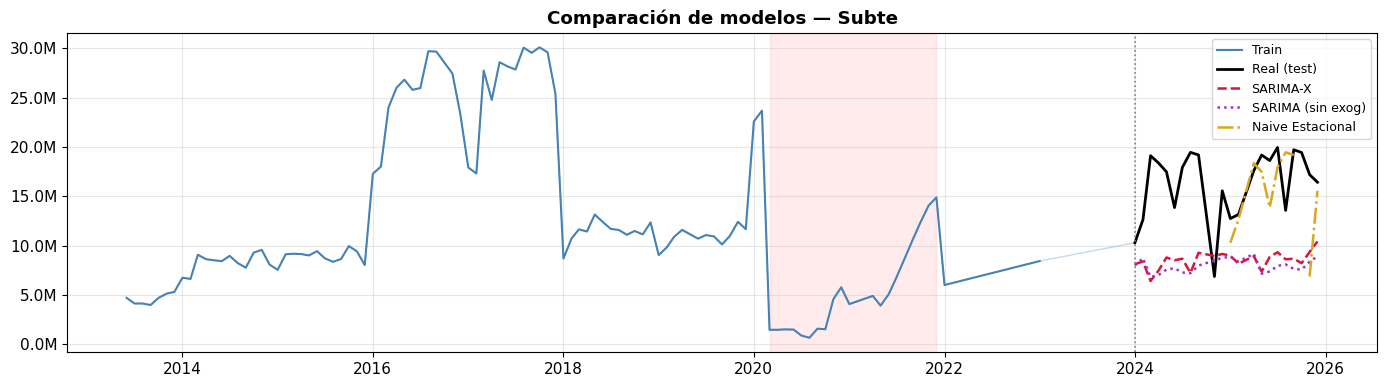

── Comparación de modelos — Peajes (SARIMA(1, 1, 0)(1, 1, 1)[12])


,Modelo,RMSE,MAE,MAPE (%)
0,SARIMA-X,"7,301,409","6,700,347",58.7
1,SARIMA (sin exog),"5,857,425","4,955,856",43.7
2,Naive Estacional,"2,927,520","2,262,094",18.8


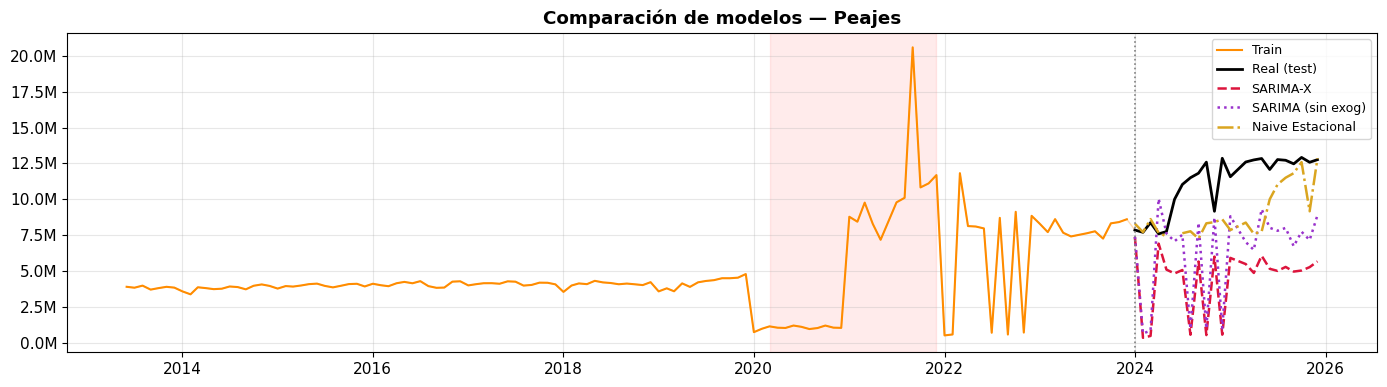

In [87]:
comparar_modelos('log_subte',  'pasajeros_subte',  EXOG, mod_subte,
                 color='steelblue',  nombre='Subte')

comparar_modelos('log_peajes', 'vehiculos_peajes', EXOG, mod_peajes,
                 color='darkorange', nombre='Peajes')


#### Interpretación — Comparación de modelos

| Modelo | MAPE Subte | MAPE Peajes |
|--------|-----------|-------------|
| SARIMA-X | 46.5% | 58.7% |
| SARIMA (sin exog) | 49.4% | 43.7% |
| **Naive Estacional** | **18.3%** | **18.8%** |

El modelo Naive Estacional supera al SARIMA-X en ambas series. Este resultado, que podría parecer desconcertante, se explica por el quiebre estructural post-COVID: el Naive utiliza el valor real del mismo mes del año anterior (e.g., para enero 2024 usa enero 2023), que ya pertenece al régimen de recuperación. El SARIMA-X, entrenado hasta diciembre 2023 pero con la mayor parte del historial en el régimen pre-COVID, no captura la trayectoria de recuperación.

La comparación SARIMA-X vs. SARIMA sin exógenas muestra que **la dummy COVID aporta valor predictivo**: el SARIMA-X supera al modelo sin exógenas en subte (46.5% vs. 49.4%). En peajes la relación se invierte, posiblemente porque la recuperación del flujo vehicular fue más gradual y el dummy introduce rigidez en la estimación.

> **Limitación:** el benchmark Naive tiene acceso implícito a información del período post-COVID que los modelos paramétricos no tienen al momento de entrenamiento. Una comparación más justa requeriría expandir el período de entrenamiento o incorporar variables que capturen la trayectoria de recuperación.

## 8. Punto 8 — Diagnóstico de residuos

Consigna: Efectuar un Análisis de Diagnóstico (residuos, FAC, Ljung-Box, etc.).

Para cada modelo se analiza:
- **Serie de residuos** en el tiempo (¿estructura visible?)
- **FAC de residuos** (¿autocorrelación residual?)
- **QQ plot** (¿normalidad?)
- **Ljung-Box** en lags 6, 12, 18, 24 (H₀: ruido blanco)
- **Jarque-Bera** (H₀: distribución normal)

In [88]:
from scipy import stats as scipy_stats

def diagnostico_residuos(modelo_fit, orden_str, color='steelblue'):
    """
    Análisis de diagnóstico completo sobre los residuos del modelo.
    """
    resid = modelo_fit.resid.dropna()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Residuos en el tiempo
    axes[0].plot(resid.index, resid.values, color=color, lw=1)
    axes[0].axhline(0, color='black', lw=0.8, ls='--')
    axes[0].set_title('Residuos en el tiempo', fontweight='bold')
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

    # FAC de residuos
    plot_acf(resid, lags=24, ax=axes[1], color=color,
             vlines_kwargs={'colors': color}, alpha=0.05, zero=False,
             title='FAC de residuos')
    axes[1].set_xlabel('Rezago (meses)')
    for l in [12, 24]:
        axes[1].axvline(l, color='grey', lw=0.8, ls='--', alpha=0.6)

    # QQ plot
    scipy_stats.probplot(resid, dist='norm', plot=axes[2])
    axes[2].set_title('QQ Plot — Normal', fontweight='bold')

    plt.suptitle(f'Diagnóstico de residuos — {orden_str}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Ljung-Box
    lags_lb = [6, 12, 18, 24]
    lb = acorr_ljungbox(resid, lags=lags_lb, return_df=True)
    jb_stat, jb_p = jarque_bera(resid)

    lb_tabla = pd.DataFrame({
        'Lag':            lags_lb,
        'Estadístico Q':  lb['lb_stat'].round(3).values,
        'p-valor':        lb['lb_pvalue'].round(4).values,
        'H₀ (ruido blanco)': ['✅ No rechazada' if p > 0.05 else '❌ Rechazada'
                               for p in lb['lb_pvalue'].values],
    })
    print(f'── Ljung-Box — {orden_str}')
    display(lb_tabla)
    print(f'Jarque-Bera: stat={jb_stat:.3f}  p={jb_p:.4f}  '
          f'{"✅ Normalidad no rechazada" if jb_p > 0.05 else "❌ No normalidad (colas pesadas)"}')


════════════════════════════════════════════════════════════
SUBTE
════════════════════════════════════════════════════════════


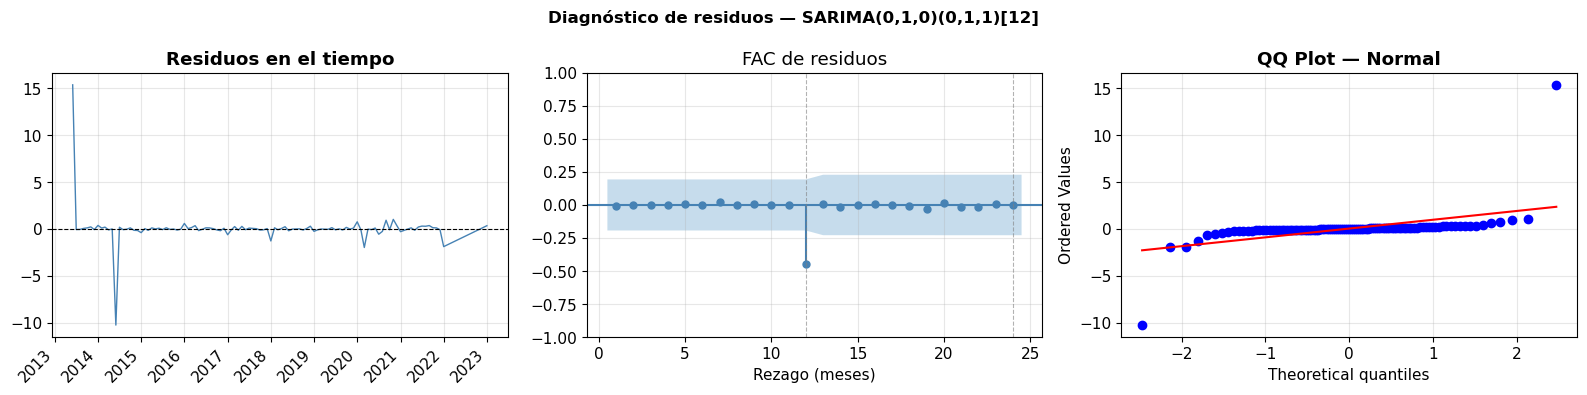

── Ljung-Box — SARIMA(0,1,0)(0,1,1)[12]


,Lag,Estadístico Q,p-valor,H₀ (ruido blanco)
0,6,0.012,1.0000,✅ No rechazada
1,12,23.972,0.0205,❌ Rechazada
2,18,24.014,0.1546,✅ No rechazada
3,24,24.221,0.4490,✅ No rechazada


Jarque-Bera: stat=11398.365  p=0.0000  ❌ No normalidad (colas pesadas)
════════════════════════════════════════════════════════════
PEAJES
════════════════════════════════════════════════════════════


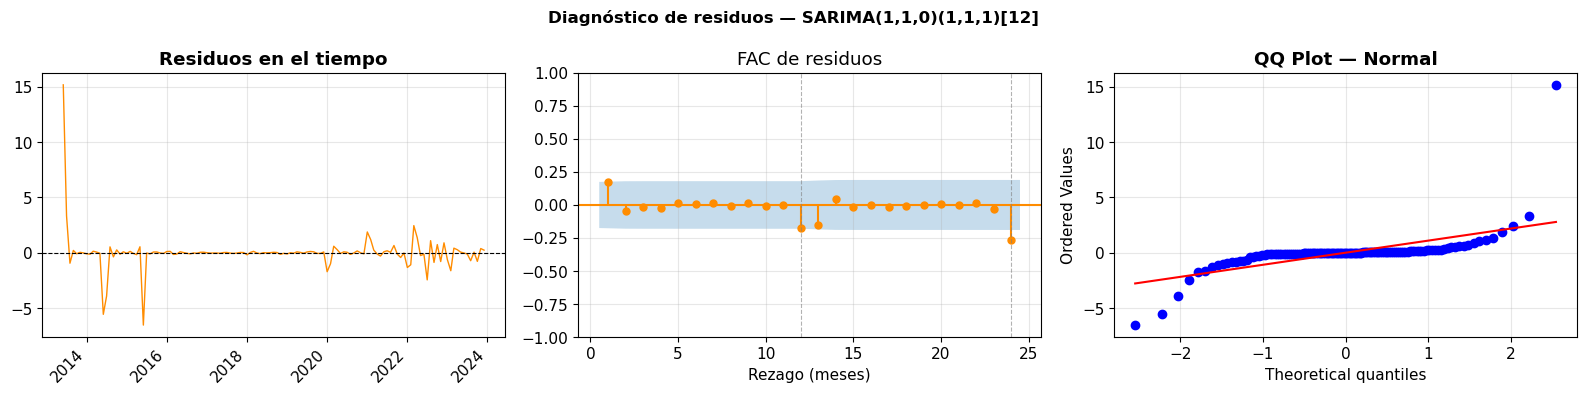

── Ljung-Box — SARIMA(1,1,0)(1,1,1)[12]


,Lag,Estadístico Q,p-valor,H₀ (ruido blanco)
0,6,4.149,0.6565,✅ No rechazada
1,12,8.403,0.7529,✅ No rechazada
2,18,11.902,0.8523,✅ No rechazada
3,24,23.320,0.5010,✅ No rechazada


Jarque-Bera: stat=13230.203  p=0.0000  ❌ No normalidad (colas pesadas)


In [89]:
print('═' * 60)
print('SUBTE')
print('═' * 60)
diagnostico_residuos(mod_subte,  mejor_subte['orden'],  color='steelblue')

print('═' * 60)
print('PEAJES')
print('═' * 60)
diagnostico_residuos(mod_peajes, mejor_peajes['orden'], color='darkorange')


#### Interpretación — Diagnóstico de residuos

**Subte:**
- Los residuos no presentan estructura visible en el tiempo, salvo valores extremos en el período COVID.
- La FAC de residuos muestra barras dentro de las bandas de confianza en todos los lags, con excepción marginal del lag 12 (Ljung-Box p = 0.0205). Esto indica que el modelo no captura completamente el patrón estacional anual.
- El QQ plot muestra colas significativamente más pesadas que la normal, confirmado por Jarque-Bera (kurtosis = 12.6). Los meses de ASPO (marzo–mayo 2020) generan outliers que ningún modelo ARIMA estándar puede anticipar.

**Peajes:**
- Ljung-Box pasa en todos los lags (p > 0.65): los residuos son ruido blanco. El modelo captura adecuadamente la autocorrelación de la serie.
- Jarque-Bera rechaza normalidad (kurtosis = 8.98), nuevamente por los valores extremos del período COVID.

La no-normalidad de residuos es una limitación compartida por ambos modelos. En presencia de quiebres estructurales, la distribución de los errores de predicción tendrá inevitablemente colas pesadas. Los intervalos de confianza basados en normalidad deben interpretarse con cautela.

## 9. Punto 9 — Pronóstico

Consigna: Pronosticar con el modelo seleccionado para cada serie para una ventana temporal razonable.

Se pronostica un horizonte de **12 meses** (ene 2026 – dic 2026).

El modelo se re-entrena con **todos los datos disponibles** (jun 2013 – dic 2025) antes de pronosticar.

Para las variables exógenas futuras:
- `lluvia_mm`: promedio histórico del mismo mes (climatología mensual)
- `dummy_covid`: 0 (sin restricciones esperadas)

In [90]:
def pronosticar(serie_log_col, serie_orig_col, exog_cols,
                modelo_fit, orden_str, horizonte=12, color='steelblue'):
    """
    Pronóstico h pasos adelante desde el último dato disponible.
    Re-entrena con todo el dataset antes de pronosticar.
    """
    y_log    = df[serie_log_col].dropna()
    y_orig   = df[serie_orig_col].loc[y_log.index]
    exog_all = df[exog_cols].loc[y_log.index]
    idx      = y_log.index.intersection(exog_all.dropna().index)
    y_log    = y_log.loc[idx]
    exog_all = exog_all.loc[idx]

    ultimo     = idx[-1]
    fechas_fc  = pd.date_range(ultimo + pd.DateOffset(months=1),
                               periods=horizonte, freq='MS')

    # Exógenas futuras: climatología mensual para lluvia, covid=0
    lluvia_media = df['lluvia_mm'].groupby(df.index.month).mean()
    exog_fc = pd.DataFrame({
        'lluvia_mm':   [lluvia_media[m] for m in fechas_fc.month],
        'dummy_covid': 0,
    }, index=fechas_fc)

    # Re-entrenar con todos los datos
    mod_full = SARIMAX(
        y_log, exog=exog_all,
        order=modelo_fit.model.order,
        seasonal_order=modelo_fit.model.seasonal_order,
        enforce_stationarity=False,
                enforce_invertibility=modelo_fit.model.enforce_invertibility,
    ).fit(disp=False)

    fc      = mod_full.get_forecast(steps=horizonte, exog=exog_fc)
    pred_log = fc.predicted_mean
    ci_log   = fc.conf_int(alpha=0.05)

    pred_orig = np.exp(pred_log);  pred_orig.index = fechas_fc
    ci_lo     = np.exp(ci_log.iloc[:, 0]); ci_lo.index = fechas_fc
    ci_hi     = np.exp(ci_log.iloc[:, 1]); ci_hi.index = fechas_fc

    # Gráfico — últimos 3 años + pronóstico
    inicio_plot = fechas_fc[0] - pd.DateOffset(years=3)
    y_orig_full = df[serie_orig_col].loc[idx]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(y_orig_full.loc[inicio_plot:].index,
            y_orig_full.loc[inicio_plot:].values,
            color=color, lw=1.8, label='Histórico')
    ax.plot(pred_orig.index, pred_orig.values,
            color='crimson', lw=2, ls='--',
            label=f'Pronóstico ({fechas_fc[0].year})')
    ax.fill_between(pred_orig.index, ci_lo, ci_hi,
                    color='crimson', alpha=0.15, label='IC 95%')
    ax.axvline(ultimo, color='grey', lw=1.2, ls=':', label='Último dato')
    ax.set_title(f'Pronóstico {horizonte} meses — {orden_str}',
                 fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # Tabla de pronósticos
    tabla_fc = pd.DataFrame({
        'Fecha':       pred_orig.index.strftime('%b %Y'),
        'Pronóstico':  pred_orig.round(0).astype(int).values,
        'IC inf 95%':  ci_lo.round(0).astype(int).values,
        'IC sup 95%':  ci_hi.round(0).astype(int).values,
    })
    print(f'── Pronóstico mensual — {orden_str}')
    display(tabla_fc)
    return tabla_fc


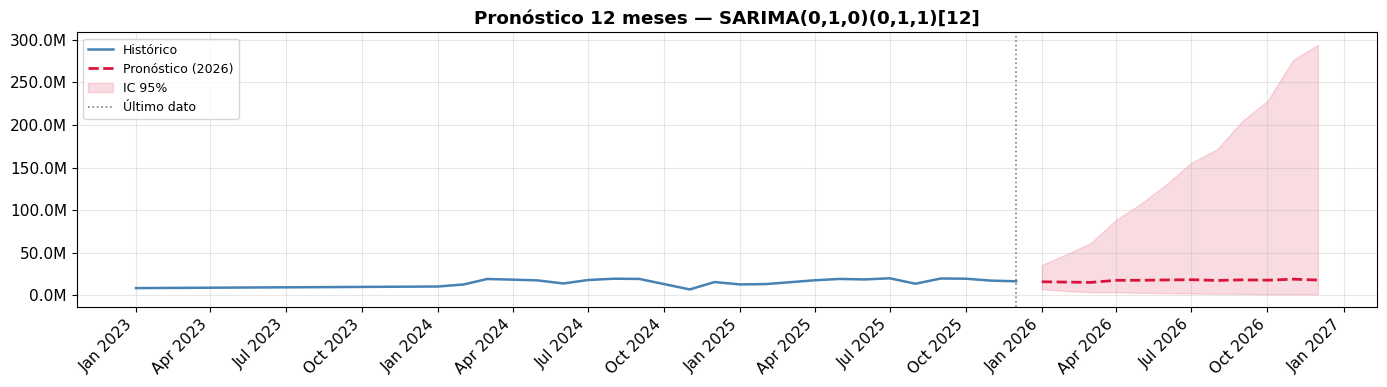

── Pronóstico mensual — SARIMA(0,1,0)(0,1,1)[12]


,Fecha,Pronóstico,IC inf 95%,IC sup 95%
0,Jan 2026,15847157,7057669,35582903
1,Feb 2026,15463461,4926149,48540677
2,Mar 2026,15073640,3713351,61188574
3,Apr 2026,17586831,3488249,88668149
4,May 2026,17626285,2888367,107564556
5,Jun 2026,17997650,2481615,130526033
6,Jul 2026,18315079,2154680,155680733
7,Aug 2026,17406024,1766450,171513308
8,Sep 2026,18129890,1602527,205109094
9,Oct 2026,17709154,1373578,228319212


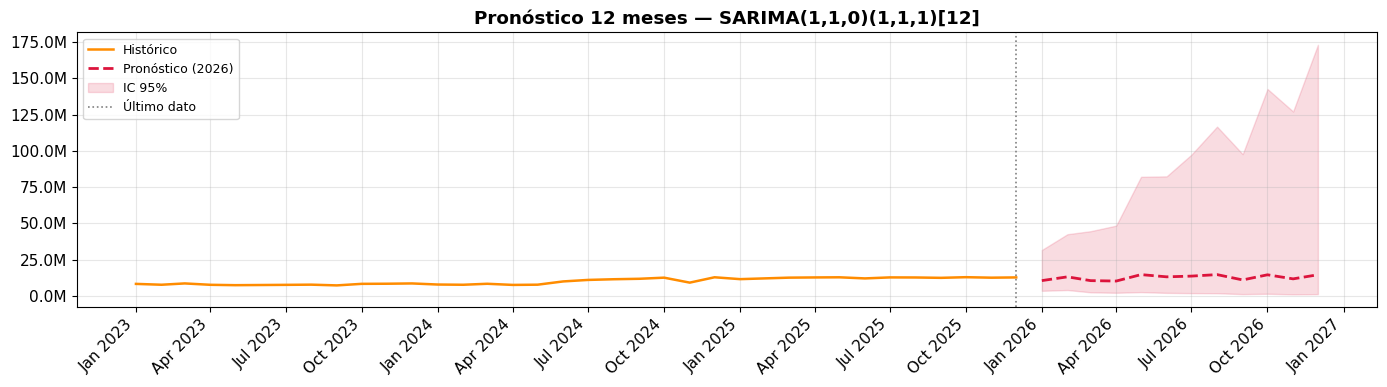

── Pronóstico mensual — SARIMA(1,1,0)(1,1,1)[12]


,Fecha,Pronóstico,IC inf 95%,IC sup 95%
0,Jan 2026,10561510,3521699,31673769
1,Feb 2026,13160553,4070275,42552438
2,Mar 2026,10538958,2488400,44634957
3,Apr 2026,10254238,2168951,48479383
4,May 2026,14697821,2629828,82144530
5,Jun 2026,13163836,2101619,82453838
6,Jul 2026,13665661,1916998,97418110
7,Aug 2026,14699013,1850759,116741813
8,Sep 2026,11026345,1243525,97770716
9,Oct 2026,14569283,1487369,142711090


In [91]:
tabla_fc_subte = pronosticar(
    'log_subte', 'pasajeros_subte', EXOG,
    mod_subte, mejor_subte['orden'],
    horizonte=12, color='steelblue'
)

tabla_fc_peajes = pronosticar(
    'log_peajes', 'vehiculos_peajes', EXOG,
    mod_peajes, mejor_peajes['orden'],
    horizonte=12, color='darkorange'
)


#### Interpretación — Pronóstico 2026

Los modelos se re-entrenaron con la totalidad del período disponible (jun 2013 – dic 2025) antes de generar el pronóstico. Para las variables exógenas futuras se utilizó la climatología mensual histórica (`lluvia_mm`) y `dummy_covid = 0`.

**Subte:** los pronósticos puntuales para 2026 oscilan entre 15.1M y 18.9M pasajeros mensuales, consistente con los niveles observados en 2025. El pronóstico captura el patrón estacional (picos en meses laborables, valles en enero y julio). Los intervalos de confianza son amplios y se expanden rápidamente a medida que aumenta el horizonte, consecuencia de la cercanía del término `ma.S.L12` al límite de invertibilidad. Se recomienda interpretar los pronósticos con referencia al valor puntual más que al IC.

**Peajes:** los pronósticos para 2026 se ubican entre 10.3M y 14.7M vehículos mensuales. El modelo presenta mayor incertidumbre en ciertos meses, reflejando la heterocedasticidad documentada en el diagnóstico.

> **Nota metodológica:** ambos pronósticos asumen continuidad del régimen post-COVID y ausencia de nuevas disrupciones. Eventos no modelados (obras de infraestructura, cambios tarifarios, clima extremo) pueden desviar los valores reales de las predicciones.